# Analysis and plotting: broad all-dynamics, multi-topology benchmark

This notebook performs **no model training**.

It reconstructs the complete result tables directly from the persistent cache
written by:

`experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed.ipynb`

You can therefore change every figure, font, label, axis, style, or export
format without rerunning a single learned trajectory.

## Plot-style toggle

At the top of the notebook choose:

```python
PLOT_STYLE = "paper_bw"
```

for simple publication-oriented figures designed to survive grayscale /
black-and-white printing, or:

```python
PLOT_STYLE = "explore"
```

for the more colorful figures used while exploring results.

The paper mode uses simple sans-serif fonts, grayscale fills, hatches,
linestyles, and marker differences rather than relying on color alone.

Both PNG and vector PDF export can be enabled independently.

In [22]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 280)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find repository root containing opinion_dynamics/."
    )


REPO_ROOT = find_repo_root()

RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / "experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed"
)
MANIFEST_PATH = RESULTS_DIR / "RUN_MANIFEST.json"

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Run manifest not found: {MANIFEST_PATH}\n"
        "Run the computation notebook/launcher first."
    )

RUN_MANIFEST = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)

CACHE_ROOT = Path(RUN_MANIFEST["cache_root"])
LEARNING_SEEDS = [
    int(value)
    for value in RUN_MANIFEST["learning_seeds"]
]

print("Results dir:", RESULTS_DIR)
print("Cache root:", CACHE_ROOT)
print("Git commit used for experiment:", RUN_MANIFEST["git_commit"])
print("Expected environments:", RUN_MANIFEST["n_environments"])
print(
    "Expected learned runs:",
    RUN_MANIFEST["n_learned_runs_expected"],
)

Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed
Cache root: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\broad_all_dynamics_multitopology_multiseed
Git commit used for experiment: 37c0d5e
Expected environments: 195
Expected learned runs: 585


## Plot style and export settings

In [23]:
# ---------------------------------------------------------------------------
# Change only this value to remake every figure for a different purpose.
# ---------------------------------------------------------------------------
PLOT_STYLE = "paper_bw"   # "paper_bw" or "explore"

SAVE_PNG = True
SAVE_PDF = True

if PLOT_STYLE not in {"paper_bw", "explore"}:
    raise ValueError(PLOT_STYLE)

PLOT_DIR = RESULTS_DIR / f"plots_{PLOT_STYLE}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def apply_plot_style(style: str) -> None:
    mpl.rcdefaults()

    common = {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "DejaVu Sans",
            "Arial",
            "Liberation Sans",
        ],
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }

    if style == "paper_bw":
        common.update(
            {
                "axes.grid": False,
                "axes.edgecolor": "0.15",
                "text.color": "0.1",
                "axes.labelcolor": "0.1",
                "xtick.color": "0.1",
                "ytick.color": "0.1",
            }
        )
    else:
        common.update(
            {
                "axes.grid": True,
                "grid.alpha": 0.22,
            }
        )

    mpl.rcParams.update(common)


apply_plot_style(PLOT_STYLE)

# Every policy remains distinguishable in black-and-white because marker,
# linestyle, and hatch differ even when colors disappear.
if PLOT_STYLE == "paper_bw":
    POLICY_STYLE = {
        "no control": {
            "color": "0.80",
            "marker": "x",
            "linestyle": ":",
            "hatch": "..",
        },
        "uniform": {
            "color": "0.58",
            "marker": "s",
            "linestyle": "--",
            "hatch": "//",
        },
        "learned": {
            "color": "0.18",
            "marker": "o",
            "linestyle": "-",
            "hatch": "xx",
        },
        "true graph": {
            "color": "0.38",
            "marker": "^",
            "linestyle": "-.",
            "hatch": "\\\\",
        },
    }
else:
    POLICY_STYLE = {
        "no control": {
            "color": "#7f7f7f",
            "marker": "x",
            "linestyle": ":",
            "hatch": "..",
        },
        "uniform": {
            "color": "#d08c28",
            "marker": "s",
            "linestyle": "--",
            "hatch": "//",
        },
        "learned": {
            "color": "#2b6cb0",
            "marker": "o",
            "linestyle": "-",
            "hatch": "xx",
        },
        "true graph": {
            "color": "#3b8f55",
            "marker": "^",
            "linestyle": "-.",
            "hatch": "\\\\",
        },
    }

DYNAMICS_LABELS = {
    "laplacian": "Linear",
    "coca": "COCA",
    "hegselmannkrause": "HK",
    "friedkinjohnsen": "FJ",
    "nonlinearinfluence": "Nonlinear",
    "repulsion": "Repulsion",
}

DYNAMICS_ORDER = [
    "laplacian",
    "coca",
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
    "repulsion",
]


def save_figure(fig: plt.Figure, stem: str) -> None:
    if SAVE_PNG:
        fig.savefig(PLOT_DIR / f"{stem}.png")
    if SAVE_PDF:
        fig.savefig(PLOT_DIR / f"{stem}.pdf")


print("Plot style:", PLOT_STYLE)
print("Plot output:", PLOT_DIR)

Plot style: paper_bw
Plot output: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed\plots_paper_bw


## Load and validate the persistent cache

In [24]:
def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


baseline_rows = []
learned_rows = []
missing = []

ENV_INDEX = {
    row["environment_id"]: row
    for row in RUN_MANIFEST["environments"]
}

for env_meta in RUN_MANIFEST["environments"]:
    environment_id = env_meta["environment_id"]
    cache_dir = Path(env_meta["cache_dir"])

    baseline_summary = cache_dir / "baseline_summary.json"

    if not baseline_summary.exists():
        missing.append((environment_id, "baseline"))
        continue

    baseline_rows.extend(read_json(baseline_summary))

    learned_root = cache_dir / "learned"

    for learning_seed in LEARNING_SEEDS:
        candidates = (
            list(
                learned_root.glob(
                    f"seed_{learning_seed:02d}_*/summary.json"
                )
            )
            if learned_root.exists()
            else []
        )

        if len(candidates) != 1:
            missing.append(
                (
                    environment_id,
                    f"learned_seed_{learning_seed}",
                )
            )
            continue

        learned_rows.append(read_json(candidates[0]))

if missing:
    print("First missing entries:", missing[:20])
    raise RuntimeError(
        f"Broad experiment cache incomplete: {len(missing)} missing entries."
    )

baseline_df = pd.DataFrame(baseline_rows)
learned_df = pd.DataFrame(learned_rows)

expected_envs = int(RUN_MANIFEST["n_environments"])
expected_learned = int(
    RUN_MANIFEST["n_learned_runs_expected"]
)

assert len(baseline_df) == expected_envs * 3
assert len(learned_df) == expected_learned

assert not baseline_df.duplicated(
    subset=["environment_id", "policy"]
).any()

assert not learned_df.duplicated(
    subset=["environment_id", "learning_seed"]
).any()

print("Cache validation passed.")
print("Baseline rows:", len(baseline_df))
print("Learned rows:", len(learned_df))

display(
    learned_df.groupby(
        ["scenario_class", "dynamics"],
        as_index=False,
    ).size()
)

Cache validation passed.
Baseline rows: 585
Learned rows: 585


,scenario_class,dynamics,size
0,structured_mechanism,friedkinjohnsen,45
1,structured_mechanism,hegselmannkrause,45
2,structured_mechanism,nonlinearinfluence,45
3,unstructured_random,coca,75
4,unstructured_random,friedkinjohnsen,75
5,unstructured_random,hegselmannkrause,75
6,unstructured_random,laplacian,75
7,unstructured_random,nonlinearinfluence,75
8,unstructured_random,repulsion,75


## Reconstruct environment-level paired results

In [25]:
learned_env = (
    learned_df.groupby(
        [
            "environment_id",
            "scenario_class",
            "family",
            "dynamics",
        ],
        as_index=False,
    )
    .agg(
        learned_final_mean=(
            "final_mean",
            "mean",
        ),
        learned_final_mean_seed_std=(
            "final_mean",
            "std",
        ),
        learned_mean_over_campaigns=(
            "mean_over_campaigns",
            "mean",
        ),
        learned_path_seed_std=(
            "mean_over_campaigns",
            "std",
        ),
        final_fit_model_over_identity=(
            "final_fit_model_over_identity",
            "mean",
        ),
    )
)

uniform_env = (
    baseline_df[
        baseline_df["policy"] == "uniform"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "uniform_final_mean",
            "mean_over_campaigns": "uniform_mean_over_campaigns",
        }
    )
)

oracle_env = (
    baseline_df[
        baseline_df["policy"] == "true_graph"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "oracle_final_mean",
            "mean_over_campaigns": "oracle_mean_over_campaigns",
        }
    )
)

no_control_env = (
    baseline_df[
        baseline_df["policy"] == "no_control"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "no_control_final_mean",
            "mean_over_campaigns": "no_control_mean_over_campaigns",
        }
    )
)

env_level_df = (
    learned_env
    .merge(
        uniform_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        oracle_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        no_control_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
)

env_level_df["learned_gap_final"] = (
    env_level_df["learned_final_mean"]
    - env_level_df["uniform_final_mean"]
)
env_level_df["learned_gap_path"] = (
    env_level_df["learned_mean_over_campaigns"]
    - env_level_df["uniform_mean_over_campaigns"]
)
env_level_df["oracle_gap_final"] = (
    env_level_df["oracle_final_mean"]
    - env_level_df["uniform_final_mean"]
)
env_level_df["oracle_gap_path"] = (
    env_level_df["oracle_mean_over_campaigns"]
    - env_level_df["uniform_mean_over_campaigns"]
)

env_level_df["oracle_advantage_recovered"] = np.where(
    np.abs(env_level_df["oracle_gap_final"]) > 1e-12,
    (
        env_level_df["learned_gap_final"]
        / env_level_df["oracle_gap_final"]
    ),
    np.nan,
)

baseline_df.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False,
)
learned_df.to_csv(
    RESULTS_DIR / "learned_seed_results.csv",
    index=False,
)
env_level_df.to_csv(
    RESULTS_DIR / "environment_level_results.csv",
    index=False,
)

display(env_level_df.head().round(5))

,environment_id,scenario_class,family,dynamics,learned_final_mean,learned_final_mean_seed_std,learned_mean_over_campaigns,learned_path_seed_std,final_fit_model_over_identity,uniform_final_mean,uniform_mean_over_campaigns,oracle_final_mean,oracle_mean_over_campaigns,no_control_final_mean,no_control_mean_over_campaigns,learned_gap_final,learned_gap_path,oracle_gap_final,oracle_gap_path,oracle_advantage_recovered
0,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.55249,0.05809,0.49184,0.03656,0.85506,0.41569,0.38387,0.62371,0.53865,0.31300,0.31846,0.13680,0.10797,0.20802,0.15478,0.65764
1,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.51599,0.05754,0.46731,0.03783,0.83901,0.41041,0.37842,0.62004,0.53436,0.30678,0.31241,0.10557,0.08890,0.20963,0.15594,0.50362
2,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.55300,0.05677,0.49175,0.04072,0.85211,0.41653,0.38478,0.62333,0.53855,0.31397,0.31946,0.13647,0.10698,0.20680,0.15378,0.65992
3,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.52171,0.05943,0.46811,0.04218,0.83439,0.41642,0.38464,0.62452,0.53953,0.31385,0.31931,0.10530,0.08347,0.20811,0.15489,0.50597
4,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.51806,0.05807,0.46991,0.03807,0.84019,0.41388,0.38197,0.62227,0.53699,0.31087,0.31635,0.10418,0.08795,0.20838,0.15503,0.49992


## Head-to-head metrics

In [26]:
def mean_ci95(values: np.ndarray) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    mean = float(values.mean())

    if len(values) == 1:
        return mean, np.nan

    half = float(
        1.96
        * values.std(ddof=1)
        / np.sqrt(len(values))
    )
    return mean, half


def summarize_group(group: pd.DataFrame) -> dict[str, Any]:
    final_mean, final_ci = mean_ci95(
        group["learned_gap_final"].to_numpy()
    )
    path_mean, path_ci = mean_ci95(
        group["learned_gap_path"].to_numpy()
    )
    recovery_mean, recovery_ci = mean_ci95(
        group["oracle_advantage_recovered"].to_numpy()
    )

    seed_subset = learned_df[
        learned_df["environment_id"].isin(
            group["environment_id"]
        )
    ].merge(
        uniform_env,
        on="environment_id",
        how="left",
    )

    seed_gaps = (
        seed_subset["final_mean"]
        - seed_subset["uniform_final_mean"]
    )

    return {
        "n_environments": int(len(group)),
        "n_learning_runs": int(len(seed_subset)),
        "learned_minus_uniform_final_mean": final_mean,
        "final_ci95_half": final_ci,
        "learned_minus_uniform_path_mean": path_mean,
        "path_ci95_half": path_ci,
        "environment_win_rate": float(
            (group["learned_gap_final"] > 0).mean()
        ),
        "seed_run_win_rate": float(
            (seed_gaps > 0).mean()
        ),
        "oracle_gap_final_mean": float(
            group["oracle_gap_final"].mean()
        ),
        "oracle_advantage_recovered_mean": recovery_mean,
        "recovery_ci95_half": recovery_ci,
        "mean_learning_seed_std_final": float(
            group["learned_final_mean_seed_std"].mean()
        ),
        "mean_final_fit_model_over_identity": float(
            group["final_fit_model_over_identity"].mean()
        ),
    }


scenario_summary_rows = []

for (
    scenario_class,
    dynamics,
), group in env_level_df.groupby(
    ["scenario_class", "dynamics"],
    sort=False,
):
    scenario_summary_rows.append(
        {
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            **summarize_group(group),
        }
    )

scenario_summary_df = pd.DataFrame(
    scenario_summary_rows
)

family_summary_rows = []

for (
    scenario_class,
    dynamics,
    family,
), group in env_level_df.groupby(
    ["scenario_class", "dynamics", "family"],
    sort=False,
):
    family_summary_rows.append(
        {
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            "family": family,
            **summarize_group(group),
        }
    )

family_summary_df = pd.DataFrame(
    family_summary_rows
)

unstructured_summary_df = (
    scenario_summary_df[
        scenario_summary_df["scenario_class"]
        == "unstructured_random"
    ]
    .set_index("dynamics")
    .loc[DYNAMICS_ORDER]
    .reset_index()
)

structured_summary_df = (
    scenario_summary_df[
        scenario_summary_df["scenario_class"]
        == "structured_mechanism"
    ]
    .copy()
)

scenario_summary_df.to_csv(
    RESULTS_DIR / "summary_by_dynamics_scenario.csv",
    index=False,
)
family_summary_df.to_csv(
    RESULTS_DIR / "family_summary.csv",
    index=False,
)
unstructured_summary_df.to_csv(
    RESULTS_DIR / "unstructured_all_dynamics_summary.csv",
    index=False,
)
structured_summary_df.to_csv(
    RESULTS_DIR / "structured_dynamics_summary.csv",
    index=False,
)

print("UNSTRUCTURED — direct all-six head-to-head")
display(unstructured_summary_df.round(5))

print("\nSTRUCTURED — mechanism families")
display(structured_summary_df.round(5))

print("\nALL FAMILIES")
display(family_summary_df.round(5))

UNSTRUCTURED — direct all-six head-to-head


,dynamics,scenario_class,n_environments,n_learning_runs,learned_minus_uniform_final_mean,final_ci95_half,learned_minus_uniform_path_mean,path_ci95_half,environment_win_rate,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,laplacian,unstructured_random,25,75,0.08253,0.01502,0.04213,0.00806,1.00,1.00000,0.12280,0.65348,0.06398,0.01125,0.10152
1,coca,unstructured_random,25,75,0.03359,0.00834,0.02996,0.00529,1.00,0.96000,0.04532,1.23803,1.02543,0.00734,0.23950
2,hegselmannkrause,unstructured_random,25,75,0.00860,0.02835,0.01150,0.01725,0.48,0.48000,0.13551,-0.02232,0.33186,0.01496,0.68769
3,friedkinjohnsen,unstructured_random,25,75,0.00574,0.01298,0.00741,0.00918,0.60,0.61333,0.08681,0.06457,0.12481,0.00595,0.90702
4,nonlinearinfluence,unstructured_random,25,75,0.01772,0.02285,0.00848,0.01281,0.52,0.48000,0.15160,0.11521,0.14445,0.00981,0.49821
5,repulsion,unstructured_random,25,75,0.11248,0.02774,0.06194,0.01206,0.96,0.96000,0.12385,0.94761,0.24775,0.01787,0.44914



STRUCTURED — mechanism families


,scenario_class,dynamics,n_environments,n_learning_runs,learned_minus_uniform_final_mean,final_ci95_half,learned_minus_uniform_path_mean,path_ci95_half,environment_win_rate,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,structured_mechanism,friedkinjohnsen,15,45,0.1241,0.00528,0.09882,0.00344,1.0,1.0,0.19663,0.63322,0.03416,0.02012,0.85570
1,structured_mechanism,hegselmannkrause,15,45,0.1437,0.01531,0.07549,0.00846,1.0,1.0,0.22563,0.63645,0.06657,0.04369,0.73408
2,structured_mechanism,nonlinearinfluence,15,45,0.2647,0.01289,0.17204,0.00864,1.0,1.0,0.33796,0.78191,0.02620,0.00983,0.58166



ALL FAMILIES


,scenario_class,dynamics,family,n_environments,n_learning_runs,learned_minus_uniform_final_mean,final_ci95_half,learned_minus_uniform_path_mean,path_ci95_half,environment_win_rate,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,structured_mechanism,friedkinjohnsen,asymmetric_broadcast,5,15,0.11766,0.01519,0.09505,0.01010,1.00,1.00000,0.20819,0.56541,0.07473,0.05798,0.84415
1,structured_mechanism,friedkinjohnsen,dual_broadcast,5,15,0.12706,0.00061,0.10066,0.00055,1.00,1.00000,0.19069,0.66629,0.00276,0.00067,0.85166
2,structured_mechanism,friedkinjohnsen,split_broadcast,5,15,0.12759,0.00129,0.10073,0.00109,1.00,1.00000,0.19102,0.66794,0.00592,0.00172,0.87130
3,structured_mechanism,hegselmannkrause,dense_weak_bridge,5,15,0.14908,0.03147,0.08158,0.01701,1.00,1.00000,0.22907,0.65050,0.13562,0.05534,0.75161
4,structured_mechanism,hegselmannkrause,paired_bridge,5,15,0.15020,0.02196,0.08014,0.01303,1.00,1.00000,0.22674,0.66247,0.09739,0.04070,0.72812
5,structured_mechanism,hegselmannkrause,ring_bridge,5,15,0.13182,0.02802,0.06476,0.01118,1.00,1.00000,0.22107,0.59639,0.12756,0.03504,0.72250
6,structured_mechanism,nonlinearinfluence,asymmetric_broadcast,5,15,0.29700,0.01373,0.19395,0.00862,1.00,1.00000,0.35242,0.84267,0.03762,0.01780,0.61492
7,structured_mechanism,nonlinearinfluence,dual_broadcast,5,15,0.24514,0.00114,0.16045,0.00157,1.00,1.00000,0.33060,0.74149,0.00440,0.00178,0.52847
8,structured_mechanism,nonlinearinfluence,split_broadcast,5,15,0.25196,0.00554,0.16171,0.00384,1.00,1.00000,0.33084,0.76157,0.01617,0.00993,0.60159
9,unstructured_random,coca,barabasi_albert_spread,25,75,0.03359,0.00834,0.02996,0.00529,1.00,0.96000,0.04532,1.23803,1.02543,0.00734,0.23950


## Plot 1 — primary all-six unstructured result

This is the cleanest apples-to-apples comparison across all six propagation
models because every model uses the same 25 graph/opinion-seed combinations.

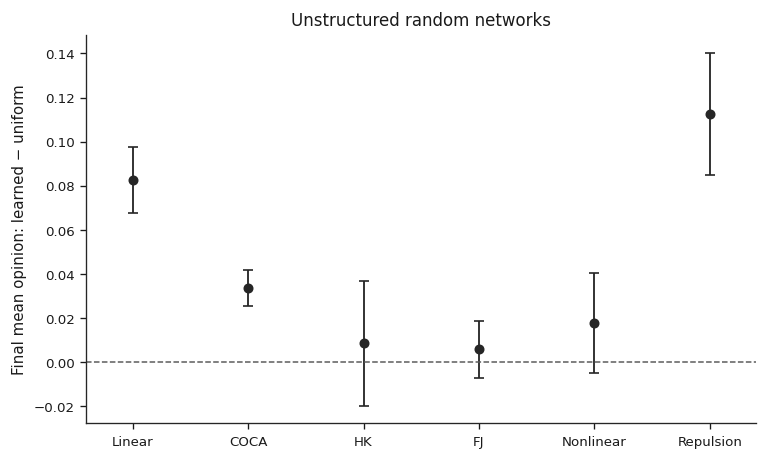

In [27]:
rows = unstructured_summary_df.copy()

means = rows["learned_minus_uniform_final_mean"].to_numpy()
cis = rows["final_ci95_half"].to_numpy()
labels = [
    DYNAMICS_LABELS[d]
    for d in rows["dynamics"]
]

fig, ax = plt.subplots(figsize=(7.2, 4.2))

x = np.arange(len(rows))

if PLOT_STYLE == "paper_bw":
    ax.errorbar(
        x,
        means,
        yerr=cis,
        fmt="o",
        markersize=5,
        linewidth=1.1,
        capsize=3,
        color="0.15",
    )
else:
    ax.errorbar(
        x,
        means,
        yerr=cis,
        fmt="o",
        markersize=6,
        linewidth=1.3,
        capsize=3,
        color=POLICY_STYLE["learned"]["color"],
    )

ax.axhline(
    0.0,
    color="0.35" if PLOT_STYLE == "paper_bw" else "0.45",
    linewidth=0.9,
    linestyle="--",
)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Unstructured random networks")
ax.margins(x=0.08)

save_figure(
    fig,
    "01_unstructured_all_dynamics_learned_minus_uniform",
)
plt.show()
plt.close(fig)

## Plot 2 — final policy performance on the matched unstructured benchmark

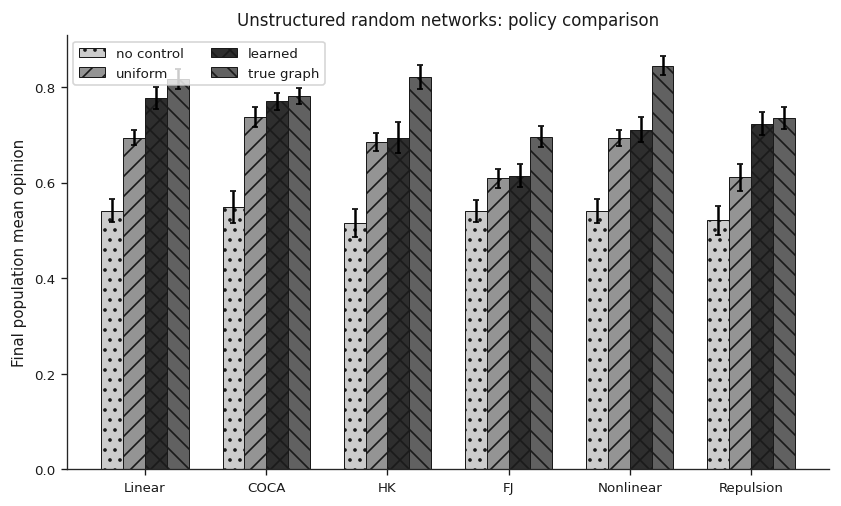

In [28]:
unstructured_env = env_level_df[
    env_level_df["scenario_class"]
    == "unstructured_random"
].copy()

policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "oracle_final_mean",
}

fig, ax = plt.subplots(figsize=(8.2, 4.7))

x = np.arange(len(DYNAMICS_ORDER))
width = 0.18

for p_index, (policy, column) in enumerate(
    policy_columns.items()
):
    means = []
    cis = []

    for dynamics in DYNAMICS_ORDER:
        group = unstructured_env[
            unstructured_env["dynamics"] == dynamics
        ]
        mean, ci = mean_ci95(group[column].to_numpy())
        means.append(mean)
        cis.append(ci)

    style = POLICY_STYLE[policy]
    xpos = x + (p_index - 1.5) * width

    bars = ax.bar(
        xpos,
        means,
        width=width,
        yerr=cis,
        capsize=2,
        label=policy,
        color=style["color"],
        edgecolor="0.1",
        linewidth=0.6,
        hatch=style["hatch"],
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [DYNAMICS_LABELS[d] for d in DYNAMICS_ORDER]
)
ax.set_ylabel("Final population mean opinion")
ax.set_title("Unstructured random networks: policy comparison")
ax.legend(ncol=2)

save_figure(
    fig,
    "02_unstructured_final_policy_comparison",
)
plt.show()
plt.close(fig)

## Plot 3 — structured-mechanism head-to-head

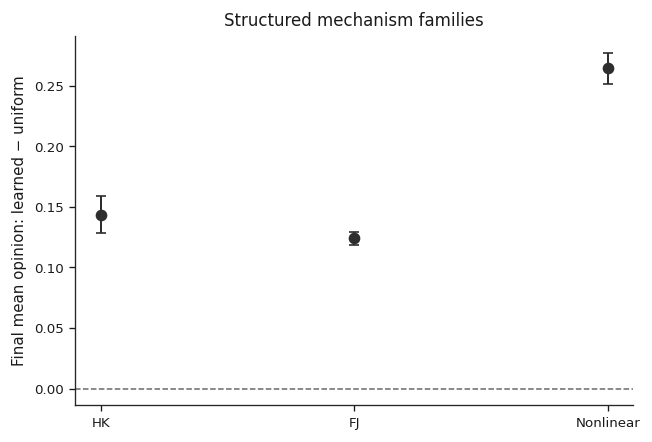

In [29]:
structured = structured_summary_df.copy()

structured_order = [
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
]
structured = (
    structured.set_index("dynamics")
    .loc[structured_order]
    .reset_index()
)

means = structured[
    "learned_minus_uniform_final_mean"
].to_numpy()
cis = structured["final_ci95_half"].to_numpy()

fig, ax = plt.subplots(figsize=(6.0, 4.0))
x = np.arange(len(structured))

ax.errorbar(
    x,
    means,
    yerr=cis,
    fmt=POLICY_STYLE["learned"]["marker"],
    markersize=6,
    linewidth=1.2,
    capsize=3,
    color=POLICY_STYLE["learned"]["color"],
)

ax.axhline(
    0.0,
    color="0.4",
    linewidth=0.9,
    linestyle="--",
)
ax.set_xticks(x)
ax.set_xticklabels(
    [DYNAMICS_LABELS[d] for d in structured["dynamics"]]
)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Structured mechanism families")

save_figure(
    fig,
    "03_structured_dynamics_learned_minus_uniform",
)
plt.show()
plt.close(fig)

## Plot 4 — family robustness

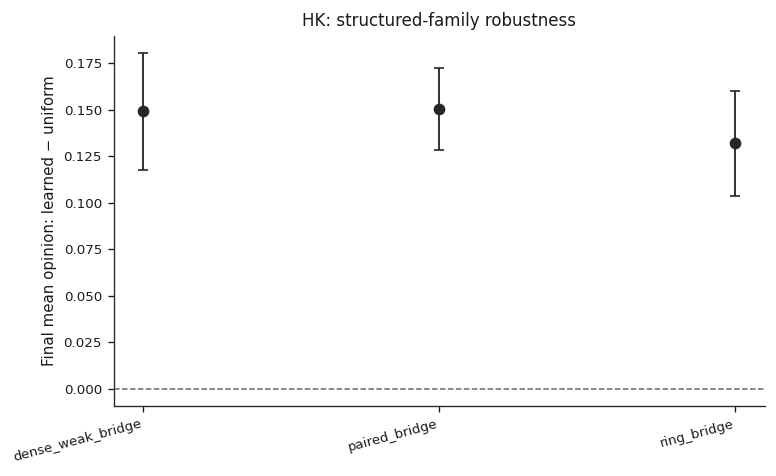

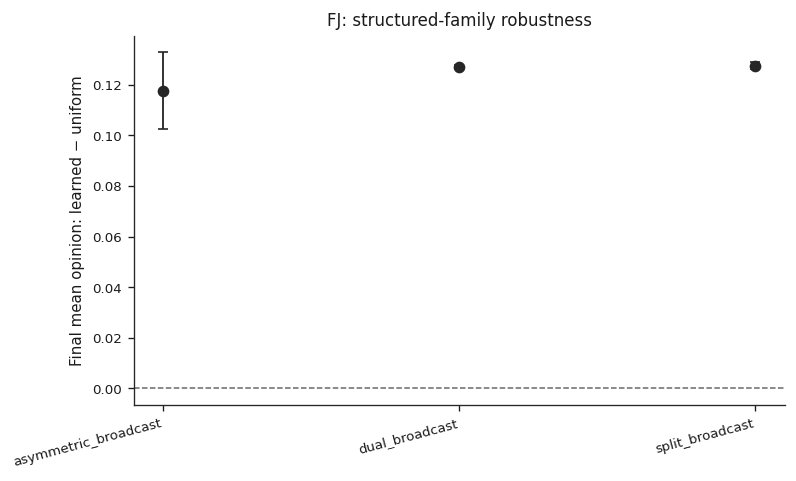

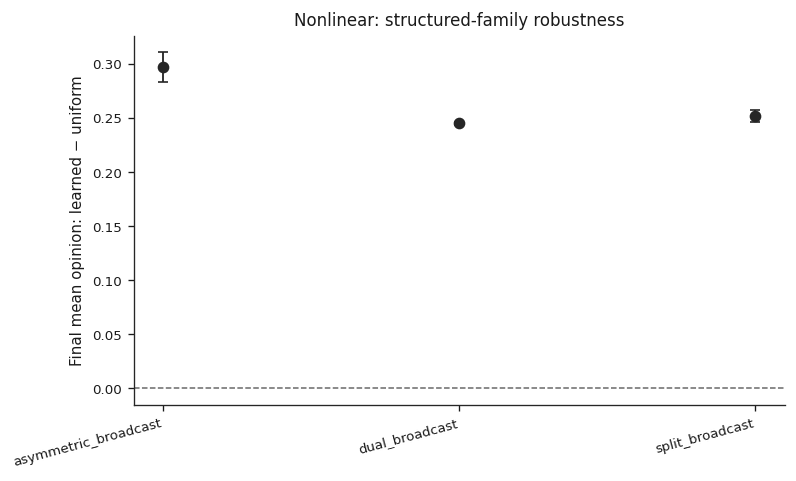

In [30]:
structured_family = family_summary_df[
    family_summary_df["scenario_class"]
    == "structured_mechanism"
].copy()

for dynamics in [
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
]:
    subset = structured_family[
        structured_family["dynamics"] == dynamics
    ].copy()

    x = np.arange(len(subset))
    means = subset[
        "learned_minus_uniform_final_mean"
    ].to_numpy()
    cis = subset["final_ci95_half"].to_numpy()

    fig, ax = plt.subplots(figsize=(7.0, 4.0))

    if PLOT_STYLE == "paper_bw":
        ax.errorbar(
            x,
            means,
            yerr=cis,
            fmt="o",
            color="0.15",
            capsize=3,
            linewidth=1.1,
        )
    else:
        ax.errorbar(
            x,
            means,
            yerr=cis,
            fmt="o",
            color=POLICY_STYLE["learned"]["color"],
            capsize=3,
            linewidth=1.2,
        )

    ax.axhline(
        0.0,
        color="0.4",
        linewidth=0.9,
        linestyle="--",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        subset["family"],
        rotation=15,
        ha="right",
    )
    ax.set_ylabel("Final mean opinion: learned − uniform")
    ax.set_title(
        f"{DYNAMICS_LABELS[dynamics]}: structured-family robustness"
    )

    save_figure(
        fig,
        f"04_family_robustness_{dynamics}",
    )
    plt.show()
    plt.close(fig)

## Plot 5 — fraction of oracle advantage recovered

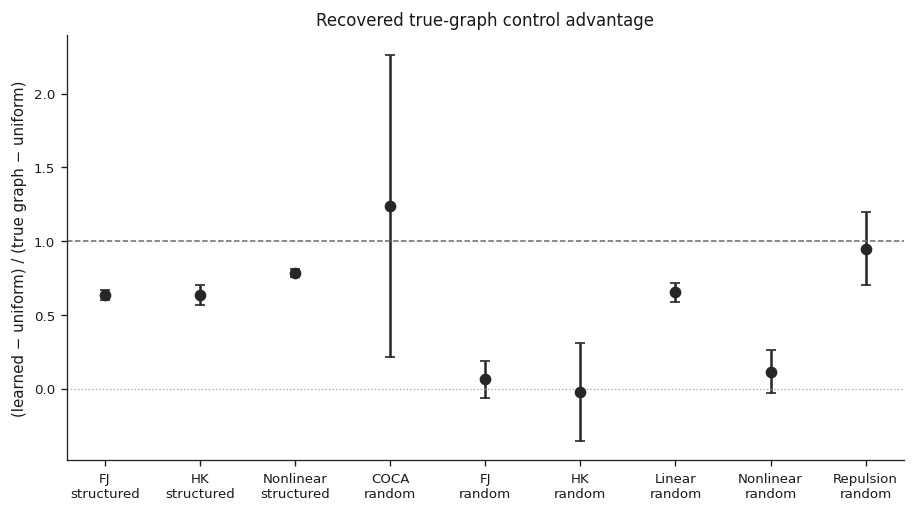

In [31]:
plot_rows = scenario_summary_df.copy()

labels = []
values = []
cis = []

for _, row in plot_rows.iterrows():
    scenario_short = (
        "random"
        if row["scenario_class"] == "unstructured_random"
        else "structured"
    )
    labels.append(
        f"{DYNAMICS_LABELS[row['dynamics']]}\n{scenario_short}"
    )
    values.append(
        row["oracle_advantage_recovered_mean"]
    )
    cis.append(
        row["recovery_ci95_half"]
    )

fig, ax = plt.subplots(figsize=(9.0, 4.6))
x = np.arange(len(labels))

ax.errorbar(
    x,
    values,
    yerr=cis,
    fmt="o",
    color=(
        "0.15"
        if PLOT_STYLE == "paper_bw"
        else POLICY_STYLE["learned"]["color"]
    ),
    capsize=3,
)

ax.axhline(
    1.0,
    color="0.4",
    linestyle="--",
    linewidth=0.9,
)
ax.axhline(
    0.0,
    color="0.65",
    linestyle=":",
    linewidth=0.8,
)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(
    "(learned − uniform) / (true graph − uniform)"
)
ax.set_title("Recovered true-graph control advantage")

save_figure(
    fig,
    "05_oracle_advantage_recovered",
)
plt.show()
plt.close(fig)

## Plot 6 — prediction fit versus control improvement

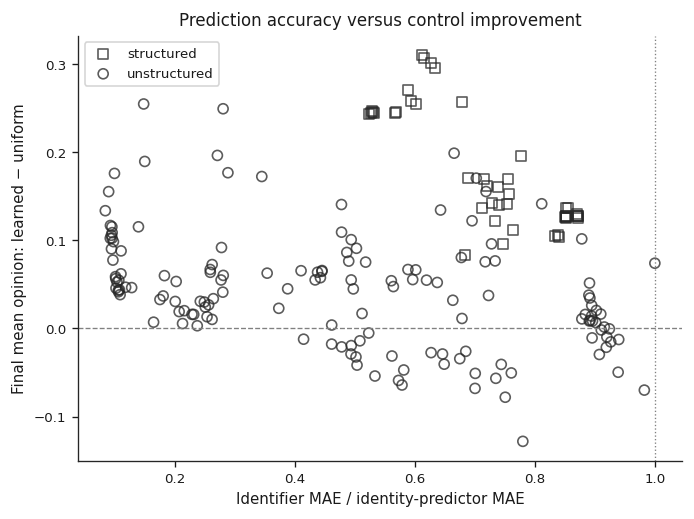

In [32]:
fig, ax = plt.subplots(figsize=(6.5, 4.6))

marker_by_scenario = {
    "unstructured_random": "o",
    "structured_mechanism": "s",
}

for scenario_class, group in env_level_df.groupby(
    "scenario_class"
):
    marker = marker_by_scenario[scenario_class]

    ax.scatter(
        group["final_fit_model_over_identity"],
        group["learned_gap_final"],
        marker=marker,
        alpha=0.75,
        label=(
            "unstructured"
            if scenario_class == "unstructured_random"
            else "structured"
        ),
        facecolors=(
            "none"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        edgecolors=(
            "0.15"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
    )

ax.axhline(
    0.0,
    color="0.5",
    linewidth=0.8,
    linestyle="--",
)
ax.axvline(
    1.0,
    color="0.5",
    linewidth=0.8,
    linestyle=":",
)
ax.set_xlabel("Identifier MAE / identity-predictor MAE")
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Prediction accuracy versus control improvement")
ax.legend()

save_figure(
    fig,
    "06_fit_vs_control_gain",
)
plt.show()
plt.close(fig)

## Cached rollout loader for trajectory plots

In [33]:
def _load_policy_from_npz(
    arrays: Any,
    policy: str,
) -> dict[str, Any]:
    inter_keys = sorted(
        key
        for key in arrays.files
        if key.startswith(
            f"{policy}__intermediate__"
        )
    )

    return {
        "policy": policy,
        "states": arrays[f"{policy}__states"],
        "actions": arrays[f"{policy}__actions"],
        "intermediate_states_list": [
            arrays[key]
            for key in inter_keys
        ],
    }


def load_baseline_rollout(
    environment_id: str,
    policy: str,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )
    arrays = np.load(
        cache_dir / "baselines.npz",
        allow_pickle=False,
    )
    return _load_policy_from_npz(arrays, policy)


def load_learned_rollout(
    environment_id: str,
    learning_seed: int,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )
    learned_root = cache_dir / "learned"

    matches = list(
        learned_root.glob(
            f"seed_{int(learning_seed):02d}_*/rollout.npz"
        )
    )
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one learned rollout for "
            f"{environment_id}, seed={learning_seed}; "
            f"found {len(matches)}"
        )

    arrays = np.load(
        matches[0],
        allow_pickle=False,
    )
    return _load_policy_from_npz(
        arrays,
        "learned_nonlinear",
    )


T_CAMPAIGN = float(
    RUN_MANIFEST["scientific_config"]["t_campaign"]
)
T_S = float(
    RUN_MANIFEST["scientific_config"]["t_s"]
)
TARGET = float(
    RUN_MANIFEST["scientific_config"]["target"]
)


def fine_trajectory(
    rollout: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray]:
    times = [0.0]
    states = [
        np.asarray(rollout["states"][0], dtype=float)
    ]

    for campaign, inter in enumerate(
        rollout["intermediate_states_list"]
    ):
        inter = np.asarray(inter, dtype=float)
        t0 = campaign * T_CAMPAIGN

        times.append(t0)
        states.append(inter[0])

        for step in range(1, len(inter)):
            times.append(t0 + step * T_S)
            states.append(inter[step])

    return (
        np.asarray(times, dtype=float),
        np.asarray(states, dtype=float),
    )


def representative_learning_seed(
    environment_id: str,
) -> int:
    rows = (
        learned_df[
            learned_df["environment_id"] == environment_id
        ]
        .sort_values("final_mean")
        .reset_index(drop=True)
    )

    median_value = float(rows["final_mean"].median())

    index = (
        rows["final_mean"] - median_value
    ).abs().idxmin()

    return int(rows.loc[index, "learning_seed"])

In [34]:
def load_environment_definition(
    environment_id: str,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )

    npz_path = cache_dir / "environment_definition.npz"
    json_path = cache_dir / "environment_definition.json"

    if not npz_path.exists() or not json_path.exists():
        raise FileNotFoundError(
            "Environment definition is missing from the cache. "
            "Run experiment_2026_08_17_broad_all_dynamics_"
            "multitopology_multiseed_BACKFILL.ipynb normally once. "
            "It only writes missing graph/opinion definitions and "
            "does NOT rerun learned models or rollouts."
        )

    arrays = np.load(
        npz_path,
        allow_pickle=False,
    )
    metadata = json.loads(
        json_path.read_text(encoding="utf-8")
    )

    result = dict(metadata)
    result["A"] = np.asarray(arrays["A"], dtype=float)
    result["x0"] = np.asarray(arrays["x0"], dtype=float)
    result["v_true"] = np.asarray(
        arrays["v_true"],
        dtype=float,
    )

    if "raw" in arrays.files:
        result["raw"] = np.asarray(
            arrays["raw"],
            dtype=float,
        )

    return result

## Predetermined representative environments

These are fixed by seed/family, not selected after inspecting the learned
outcome.

For every dynamics we show one original unstructured environment:
topology seed 3, opinion seed 0.

For the three structured models we also show the canonical structured family
used in the preceding experiment.

In [35]:
CANONICAL_UNSTRUCTURED = {
    dynamics: (
        f"unstructured__{dynamics}__topo03__x00"
    )
    for dynamics in DYNAMICS_ORDER
}

CANONICAL_STRUCTURED = {
    "hegselmannkrause": (
        "structured__hegselmannkrause"
        "__ring_bridge__env00"
    ),
    "friedkinjohnsen": (
        "structured__friedkinjohnsen"
        "__asymmetric_broadcast__env00"
    ),
    "nonlinearinfluence": (
        "structured__nonlinearinfluence"
        "__asymmetric_broadcast__env00"
    ),
}

display(
    pd.DataFrame(
        [
            {
                "dynamics": dynamics,
                "unstructured_environment": environment_id,
                "representative_learning_seed": (
                    representative_learning_seed(
                        environment_id
                    )
                ),
            }
            for dynamics, environment_id
            in CANONICAL_UNSTRUCTURED.items()
        ]
    )
)

,dynamics,unstructured_environment,representative_learning_seed
0,laplacian,unstructured__laplacian__topo03__x00,2
1,coca,unstructured__coca__topo03__x00,2
2,hegselmannkrause,unstructured__hegselmannkrause__topo03__x00,1
3,friedkinjohnsen,unstructured__friedkinjohnsen__topo03__x00,0
4,nonlinearinfluence,unstructured__nonlinearinfluence__topo03__x00,0
5,repulsion,unstructured__repulsion__topo03__x00,1


## Plot 7 — representative mean trajectories for all six dynamics

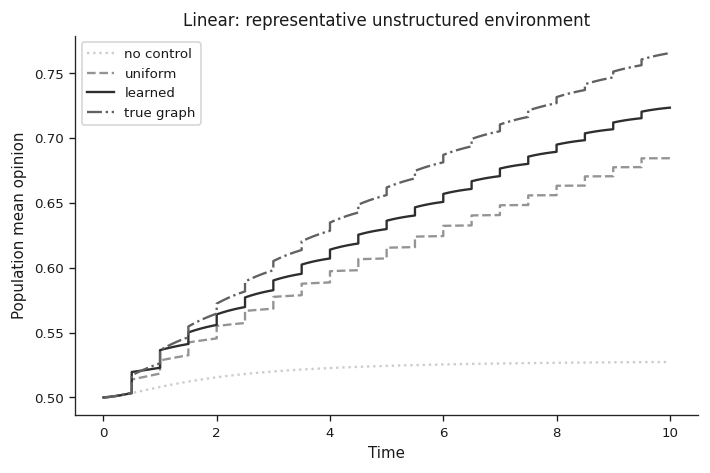

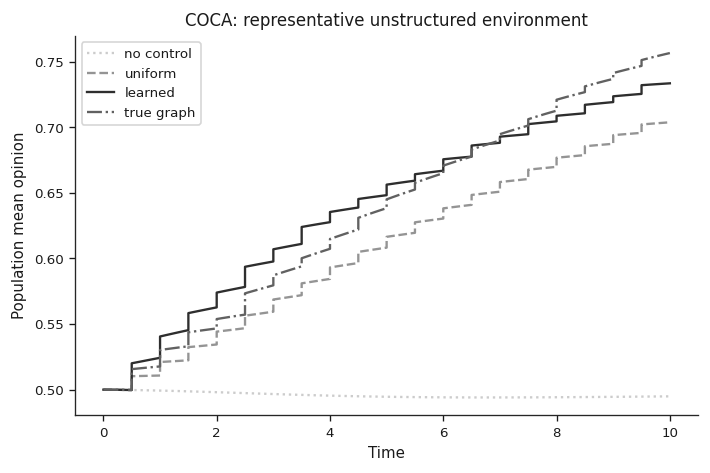

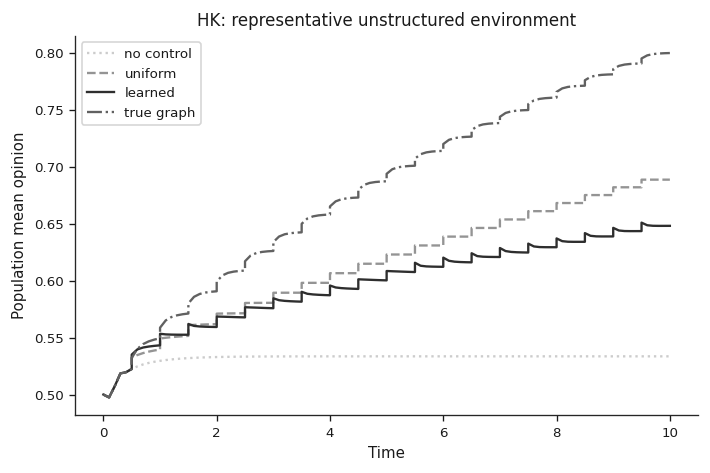

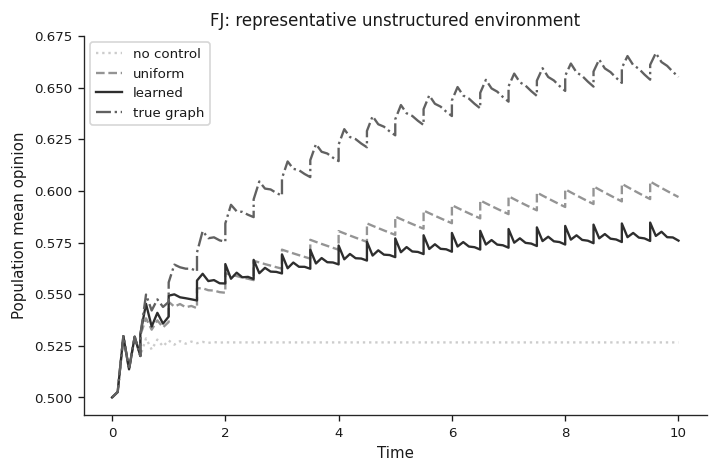

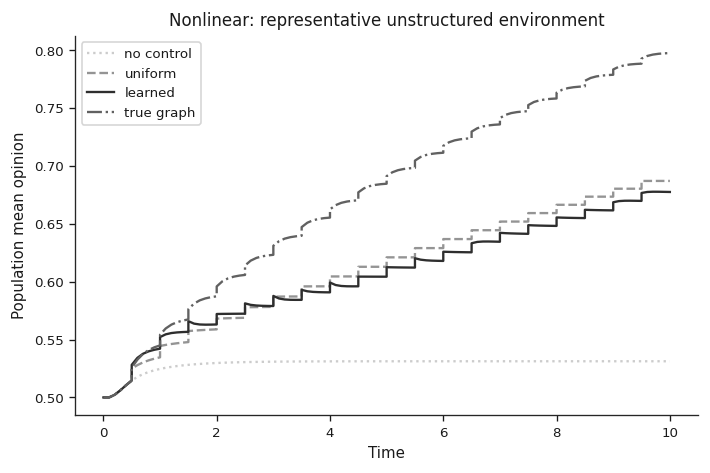

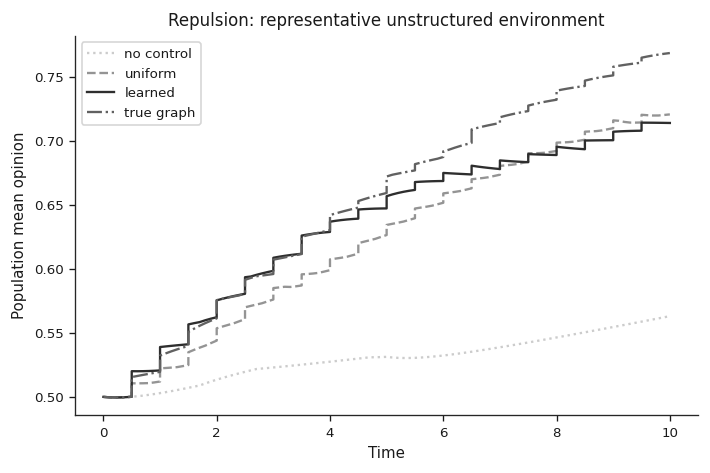

In [36]:
for dynamics in DYNAMICS_ORDER:
    environment_id = CANONICAL_UNSTRUCTURED[dynamics]
    rep_seed = representative_learning_seed(environment_id)

    rollouts = {
        "no control": load_baseline_rollout(
            environment_id,
            "no_control",
        ),
        "uniform": load_baseline_rollout(
            environment_id,
            "uniform",
        ),
        "learned": load_learned_rollout(
            environment_id,
            rep_seed,
        ),
        "true graph": load_baseline_rollout(
            environment_id,
            "true_graph",
        ),
    }

    fig, ax = plt.subplots(figsize=(6.7, 4.1))

    for policy, rollout in rollouts.items():
        times, states = fine_trajectory(rollout)
        style = POLICY_STYLE[policy]

        ax.plot(
            times,
            states.mean(axis=1),
            label=policy,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=None,
            linewidth=1.4,
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Population mean opinion")
    ax.set_title(
        f"{DYNAMICS_LABELS[dynamics]}: "
        "representative unstructured environment"
    )
    ax.legend()

    save_figure(
        fig,
        f"07_unstructured_mean_trajectory_{dynamics}",
    )
    plt.show()
    plt.close(fig)

## Plot 8 — individual-node trajectories for the canonical structured cases

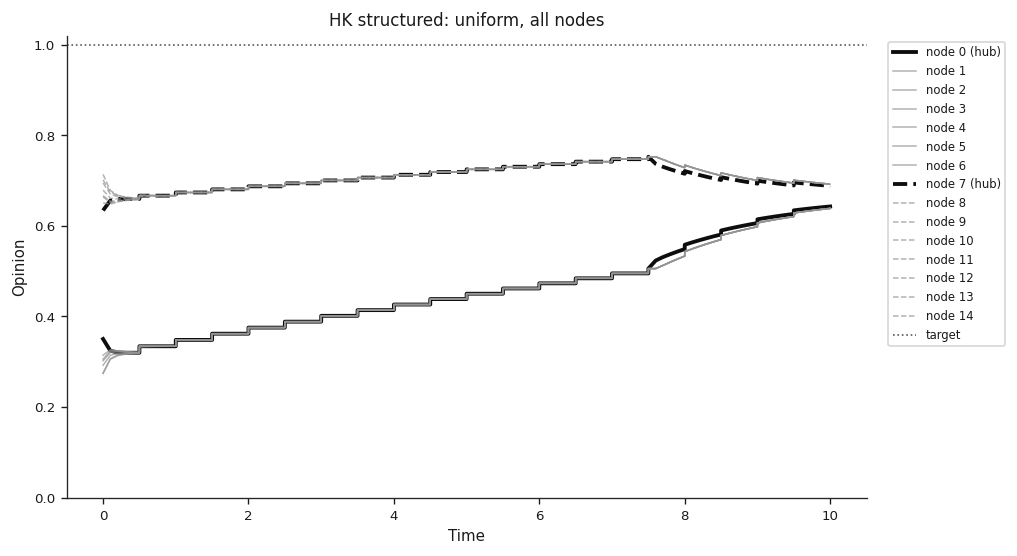

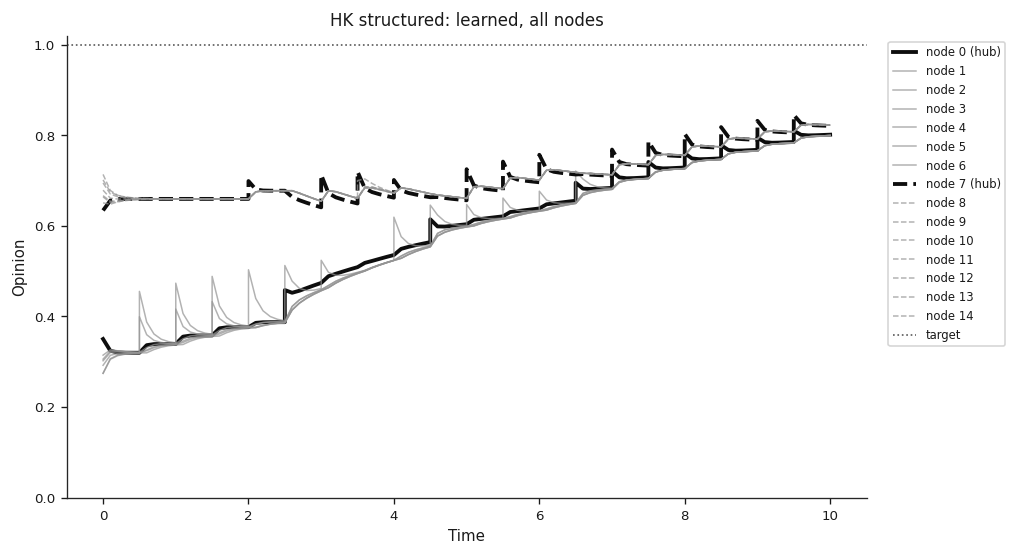

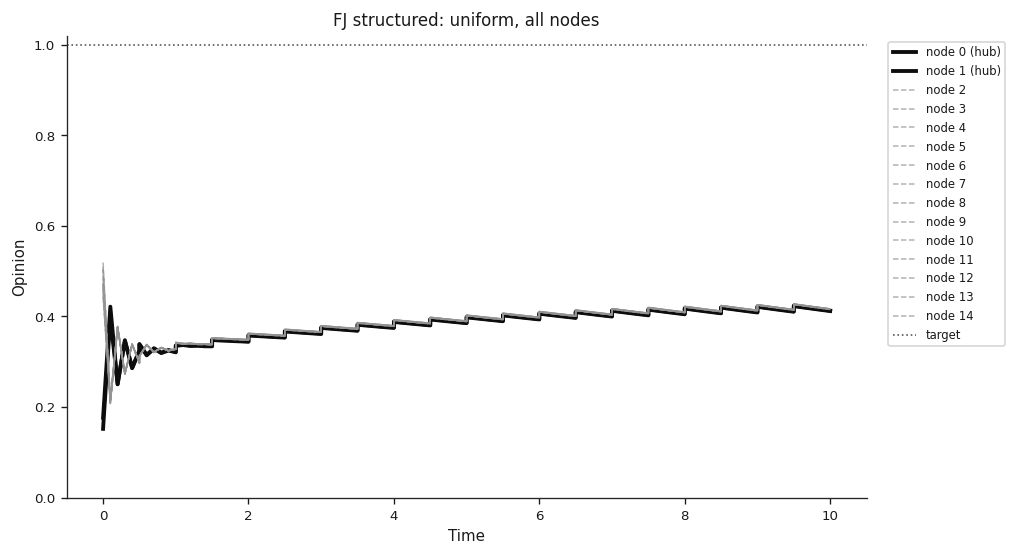

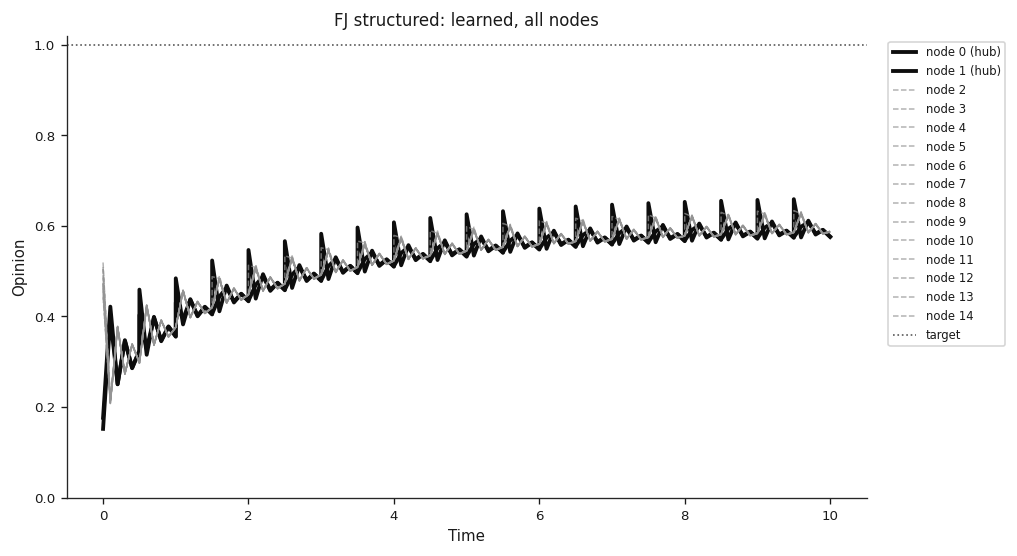

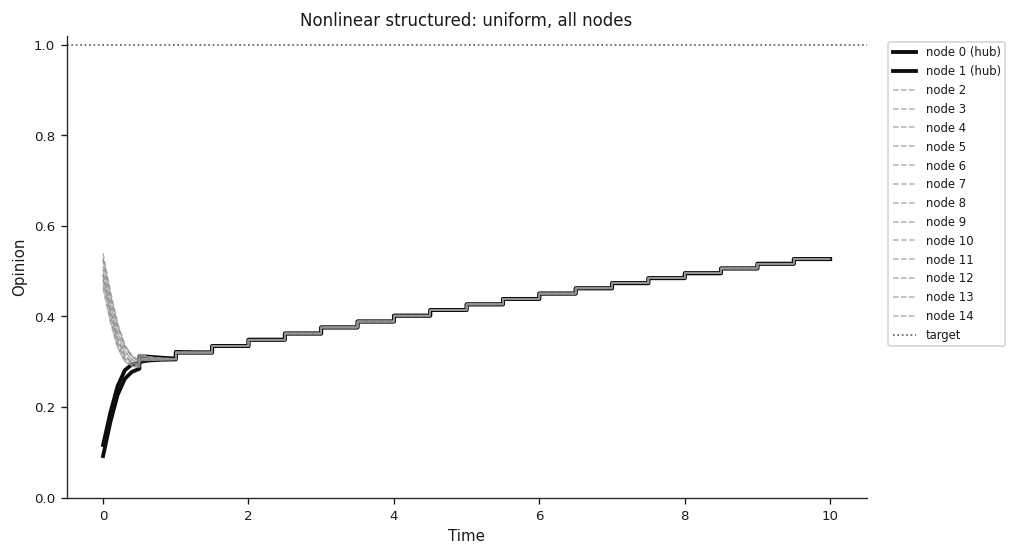

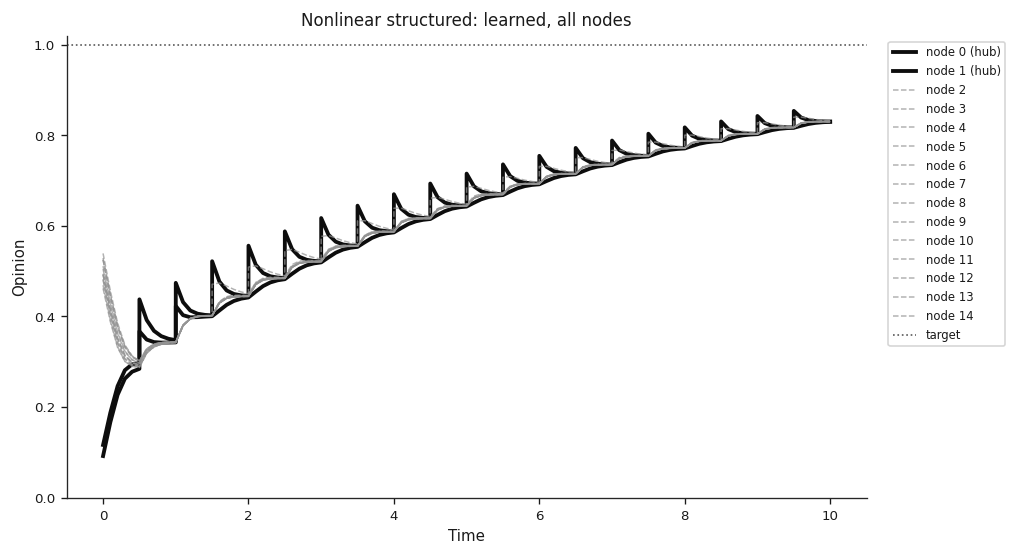

In [37]:
def plot_all_nodes(
    rollout: dict[str, Any],
    *,
    dynamics: str,
    title: str,
    stem: str,
) -> None:
    times, states = fine_trajectory(rollout)

    fig, ax = plt.subplots(figsize=(8.6, 5.0))

    if dynamics == "hegselmannkrause":
        hubs = {0, 7}
        low_cluster = set(range(0, 7))
    else:
        hubs = {0, 1}
        low_cluster = set()

    for node in range(states.shape[1]):
        is_hub = node in hubs

        if dynamics == "hegselmannkrause":
            linestyle = "-" if node in low_cluster else "--"
        else:
            linestyle = "-" if is_hub else "--"

        if PLOT_STYLE == "paper_bw":
            color = "0.05" if is_hub else "0.58"
        else:
            color = None

        ax.plot(
            times,
            states[:, node],
            linewidth=2.3 if is_hub else 0.9,
            linestyle=linestyle,
            color=color,
            alpha=1.0 if is_hub else 0.72,
            label=(
                f"node {node}"
                + (" (hub)" if is_hub else "")
            ),
        )

    ax.axhline(
        TARGET,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="target",
    )
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel("Time")
    ax.set_ylabel("Opinion")
    ax.set_title(title)
    ax.legend(
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=7,
    )

    save_figure(fig, stem)
    plt.show()
    plt.close(fig)


for dynamics, environment_id in CANONICAL_STRUCTURED.items():
    rep_seed = representative_learning_seed(environment_id)

    learned_rollout = load_learned_rollout(
        environment_id,
        rep_seed,
    )
    uniform_rollout = load_baseline_rollout(
        environment_id,
        "uniform",
    )

    plot_all_nodes(
        uniform_rollout,
        dynamics=dynamics,
        title=(
            f"{DYNAMICS_LABELS[dynamics]} structured: "
            "uniform, all nodes"
        ),
        stem=(
            f"08_structured_all_nodes_uniform_{dynamics}"
        ),
    )

    plot_all_nodes(
        learned_rollout,
        dynamics=dynamics,
        title=(
            f"{DYNAMICS_LABELS[dynamics]} structured: "
            "learned, all nodes"
        ),
        stem=(
            f"08_structured_all_nodes_learned_{dynamics}"
        ),
    )

## Plot 9 — learned action heatmaps for the structured cases

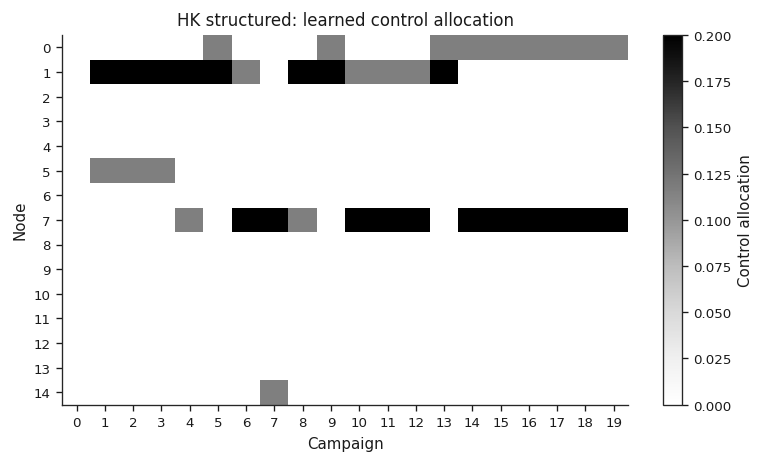

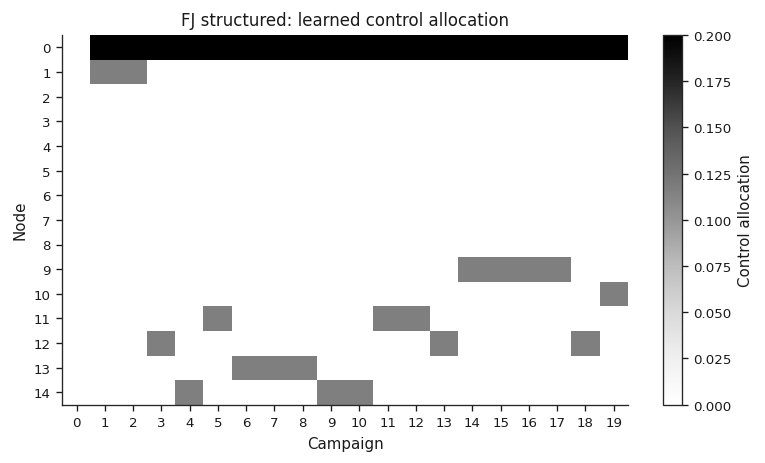

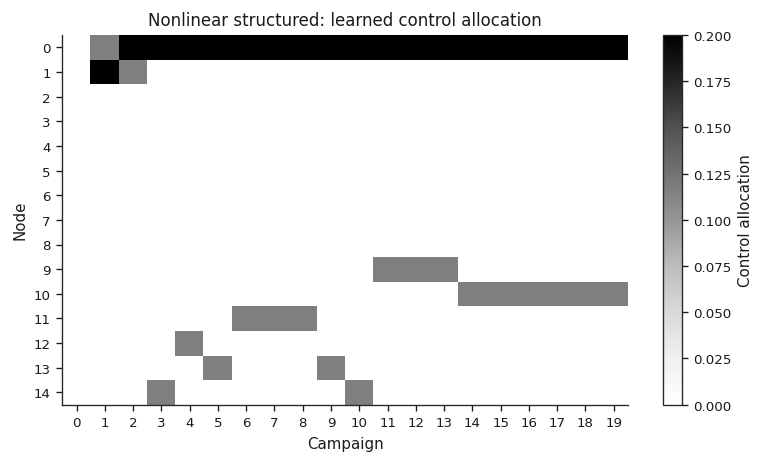

In [38]:
for dynamics, environment_id in CANONICAL_STRUCTURED.items():
    rep_seed = representative_learning_seed(environment_id)
    rollout = load_learned_rollout(
        environment_id,
        rep_seed,
    )

    actions = np.asarray(
        rollout["actions"],
        dtype=float,
    )

    fig, ax = plt.subplots(figsize=(7.6, 4.0))

    cmap = "Greys" if PLOT_STYLE == "paper_bw" else "viridis"

    image = ax.imshow(
        actions.T,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
    )
    ax.set_xlabel("Campaign")
    ax.set_ylabel("Node")
    ax.set_xticks(np.arange(actions.shape[0]))
    ax.set_yticks(np.arange(actions.shape[1]))
    ax.set_title(
        f"{DYNAMICS_LABELS[dynamics]} structured: "
        "learned control allocation"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Control allocation",
    )

    save_figure(
        fig,
        f"09_structured_learned_actions_{dynamics}",
    )
    plt.show()
    plt.close(fig)

## Benchmark-family definitions

The broad experiment contains two conceptually different kinds of environments.

### Original unstructured benchmark — `barabasi_albert_spread`

This is the **generic benchmark used before the mechanism-specific topology studies**.

For every propagation law:

- the network has 15 nodes;
- connectivity is generated from a Barabási--Albert graph with `m = 2`;
- the same five graph seeds (`3, 4, 5, 6, 7`) are reused across all six dynamics;
- the initial opinions are the 15 equally spaced values from 0 to 1,
  randomly permuted using five opinion seeds (`0, 1, 2, 4, 5`);
- therefore every dynamics model is evaluated on the same 25 graph/opinion
  combinations.

The graph is **not designed around a particular control mechanism**.
Central nodes arise naturally from preferential attachment, while opinions are deliberately spread across the full opinion interval.
This makes `barabasi_albert_spread` the main apples-to-apples benchmark for comparing all six propagation laws.

The graph generator also uses the repository's existing Barabási--Albert
pruning/validity settings (`ba_prune_max_frac = 0.5`, `ba_qsc_tol = 1e-8`,
`ba_max_tries = 500`). Those are implementation settings of the generic graph
generator rather than additional topology families.

### Structured mechanism benchmarks

The remaining families are **deliberately structured stress tests**.
They are not intended to replace the original random benchmark.
Instead, they create network configurations in which graph-aware intervention
has a specific mechanism to exploit:

- HK: activating a confidence-limited inter-cluster bridge;
- FJ: targeting influential broadcasters rather than spreading budget over followers;
- nonlinear influence: targeting influential broadcasters whose state-dependent
  interaction can otherwise oppose the control objective.

In [39]:
benchmark_family_glossary_df = pd.DataFrame(
    [
        {
            "scenario_class": "unstructured_random",
            "family": "barabasi_albert_spread",
            "dynamics": "all six dynamics",
            "graph_definition": (
                "15-node Barabasi-Albert graph, m=2, "
                "five matched topology seeds"
            ),
            "initial_opinions": (
                "15 equally spaced values on [0,1], "
                "permuted with five matched opinion seeds"
            ),
            "scientific_role": (
                "generic apples-to-apples benchmark; "
                "not designed around a specific control mechanism"
            ),
        },
        {
            "scenario_class": "structured_mechanism",
            "family": "HK bridge families",
            "dynamics": "HK",
            "graph_definition": (
                "two internally connected communities whose only "
                "cross-community topological edge is between the hubs"
            ),
            "initial_opinions": (
                "two compact opinion clusters separated beyond HK confidence"
            ),
            "scientific_role": (
                "tests whether learned targeting activates a latent bridge "
                "earlier than uniform intervention"
            ),
        },
        {
            "scenario_class": "structured_mechanism",
            "family": "broadcast families",
            "dynamics": "FJ / nonlinear influence",
            "graph_definition": (
                "two highly influential broadcaster hubs plus peripheral leaves"
            ),
            "initial_opinions": (
                "broadcaster hubs start lower than the leaf population"
            ),
            "scientific_role": (
                "tests whether learned targeting acts on influential sources "
                "rather than distributing budget across followers"
            ),
        },
    ]
)

benchmark_family_glossary_df.to_csv(
    RESULTS_DIR / "benchmark_family_glossary.csv",
    index=False,
)

display(benchmark_family_glossary_df)

,scenario_class,family,dynamics,graph_definition,initial_opinions,scientific_role
0,unstructured_random,barabasi_albert_spread,all six dynamics,"15-node Barabasi-Albert graph, m=2, five match...","15 equally spaced values on [0,1], permuted wi...",generic apples-to-apples benchmark; not design...
1,structured_mechanism,HK bridge families,HK,two internally connected communities whose onl...,two compact opinion clusters separated beyond ...,tests whether learned targeting activates a la...
2,structured_mechanism,broadcast families,FJ / nonlinear influence,two highly influential broadcaster hubs plus p...,broadcaster hubs start lower than the leaf pop...,tests whether learned targeting acts on influe...


## Structured family glossary

The structured benchmark families were intentionally designed to create **specific control bottlenecks**.

### HK families
All three HK families contain **two internally coherent clusters** connected only through the two hub nodes.
Because HK interaction depends on a confidence threshold, control works mainly by pushing the two hubs close enough that the bridge becomes active and the two clusters can start influencing one another.

- **ring_bridge**  
  Each cluster is organized as a hub with leaves plus a light ring among the leaves.  
  This is the most orderly local communication pattern.

- **paired_bridge**  
  Each cluster again has a dominant hub, but leaf-to-leaf communication happens mostly in isolated pairs.  
  This gives weaker within-cluster mixing than the ring case.

- **dense_weak_bridge**  
  Each cluster has many leaf-to-leaf links, but they are individually weak.  
  Once the bridge is activated, information can diffuse broadly because the cluster is internally well connected.

### FJ / nonlinear-influence families
These families contain **two highly central broadcaster nodes** and a population of leaves.
The broadcasters sit at lower initial opinions, while the leaves start higher.
The control problem is to decide how strongly to target the broadcasters so that their influence propagates through the rest of the network.

- **asymmetric_broadcast**  
  Both hubs influence the leaf population, but one hub is clearly the dominant broadcaster and the other is secondary.  
  This creates a strong ranking asymmetry.

- **dual_broadcast**  
  The two hubs broadcast approximately symmetrically to the same leaf population.  
  A good policy should typically use both hubs in a balanced way.

- **split_broadcast**  
  The leaf population is split into two subgroups, each mostly influenced by one broadcaster, with a weaker cross-effect from the other.  
  This creates a structured two-region intervention problem.

In [40]:
family_glossary_rows = [
    {
        "dynamics": "hegselmannkrause",
        "family": "ring_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "leaf nodes form a light ring within each cluster",
        "control_meaning": "control must pull the two hubs into confidence range so the bridge activates",
    },
    {
        "dynamics": "hegselmannkrause",
        "family": "paired_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "leaf nodes communicate mainly in disjoint pairs",
        "control_meaning": "bridge activation still depends on the hubs, but within-cluster mixing is sparser",
    },
    {
        "dynamics": "hegselmannkrause",
        "family": "dense_weak_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "many weak leaf-to-leaf links within each cluster",
        "control_meaning": "after bridge activation, diffusion can spread through the dense cluster interior",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "asymmetric_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "one hub is the dominant broadcaster and the other is secondary",
        "control_meaning": "a good policy should recognize the stronger hub and exploit the asymmetry",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "dual_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "both hubs broadcast symmetrically to the leaves",
        "control_meaning": "the policy should usually split attention across both important hubs",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "split_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "each hub mainly influences one subgroup of leaves, with weaker cross-effects",
        "control_meaning": "control must coordinate across two partially separated regions",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "asymmetric_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "one hub is the dominant broadcaster and the other is secondary",
        "control_meaning": "state-dependent interaction strength amplifies the value of identifying the main broadcaster",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "dual_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "both hubs broadcast symmetrically to the leaves",
        "control_meaning": "the policy should leverage both hubs while the nonlinear interaction law modulates propagation",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "split_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "each hub mainly influences one subgroup of leaves, with weaker cross-effects",
        "control_meaning": "the policy must exploit both topology and state-dependent interactions across the two subgroups",
    },
]

family_glossary_df = pd.DataFrame(family_glossary_rows)
family_glossary_df["dynamics_label"] = family_glossary_df["dynamics"].map(DYNAMICS_LABELS)

family_glossary_df.to_csv(
    RESULTS_DIR / "structured_family_glossary.csv",
    index=False,
)

display(
    family_glossary_df[
        [
            "dynamics_label",
            "family",
            "mechanism",
            "topology_meaning",
            "control_meaning",
        ]
    ]
)

,dynamics_label,family,mechanism,topology_meaning,control_meaning
0,HK,ring_bridge,two clusters connected only by the two hubs,leaf nodes form a light ring within each cluster,control must pull the two hubs into confidence...
1,HK,paired_bridge,two clusters connected only by the two hubs,leaf nodes communicate mainly in disjoint pairs,"bridge activation still depends on the hubs, b..."
2,HK,dense_weak_bridge,two clusters connected only by the two hubs,many weak leaf-to-leaf links within each cluster,"after bridge activation, diffusion can spread ..."
3,FJ,asymmetric_broadcast,two low-opinion broadcasters influence a highe...,one hub is the dominant broadcaster and the ot...,a good policy should recognize the stronger hu...
4,FJ,dual_broadcast,two low-opinion broadcasters influence a highe...,both hubs broadcast symmetrically to the leaves,the policy should usually split attention acro...
5,FJ,split_broadcast,two low-opinion broadcasters influence a highe...,each hub mainly influences one subgroup of lea...,control must coordinate across two partially s...
6,Nonlinear,asymmetric_broadcast,two low-opinion broadcasters influence a highe...,one hub is the dominant broadcaster and the ot...,state-dependent interaction strength amplifies...
7,Nonlinear,dual_broadcast,two low-opinion broadcasters influence a highe...,both hubs broadcast symmetrically to the leaves,the policy should leverage both hubs while the...
8,Nonlinear,split_broadcast,two low-opinion broadcasters influence a highe...,each hub mainly influences one subgroup of lea...,the policy must exploit both topology and stat...


## Structured family-level head-to-head summary

This is the compact quantitative view of the table you shared.  
Each point is the **environment-level mean** of

\[
\text{learned final mean opinion} - \text{uniform final mean opinion}
\]

with a 95% confidence interval over the five distinct environments in that family.

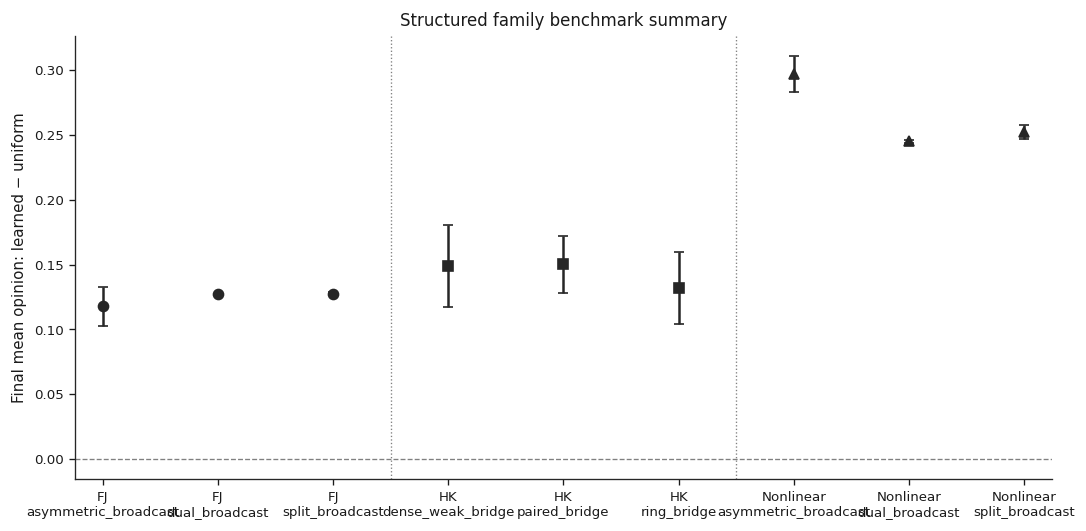

,dynamics,family,learned_minus_uniform_final_mean,final_ci95_half,environment_win_rate,oracle_advantage_recovered_mean
0,friedkinjohnsen,asymmetric_broadcast,0.11766,0.01519,1.0,0.56541
1,friedkinjohnsen,dual_broadcast,0.12706,0.00061,1.0,0.66629
2,friedkinjohnsen,split_broadcast,0.12759,0.00129,1.0,0.66794
3,hegselmannkrause,dense_weak_bridge,0.14908,0.03147,1.0,0.65050
4,hegselmannkrause,paired_bridge,0.15020,0.02196,1.0,0.66247
5,hegselmannkrause,ring_bridge,0.13182,0.02802,1.0,0.59639
6,nonlinearinfluence,asymmetric_broadcast,0.29700,0.01373,1.0,0.84267
7,nonlinearinfluence,dual_broadcast,0.24514,0.00114,1.0,0.74149
8,nonlinearinfluence,split_broadcast,0.25196,0.00554,1.0,0.76157


In [41]:
structured_family_plot_df = family_summary_df[
    family_summary_df["scenario_class"] == "structured_mechanism"
].copy()

structured_family_order = [
    ("friedkinjohnsen", "asymmetric_broadcast"),
    ("friedkinjohnsen", "dual_broadcast"),
    ("friedkinjohnsen", "split_broadcast"),
    ("hegselmannkrause", "dense_weak_bridge"),
    ("hegselmannkrause", "paired_bridge"),
    ("hegselmannkrause", "ring_bridge"),
    ("nonlinearinfluence", "asymmetric_broadcast"),
    ("nonlinearinfluence", "dual_broadcast"),
    ("nonlinearinfluence", "split_broadcast"),
]

structured_family_plot_df["order_key"] = structured_family_plot_df.apply(
    lambda row: structured_family_order.index((row["dynamics"], row["family"])),
    axis=1,
)
structured_family_plot_df = structured_family_plot_df.sort_values("order_key").reset_index(drop=True)

labels = [
    f"{DYNAMICS_LABELS[d]}\n{f}"
    for d, f in zip(
        structured_family_plot_df["dynamics"],
        structured_family_plot_df["family"],
    )
]

means = structured_family_plot_df["learned_minus_uniform_final_mean"].to_numpy()
cis = structured_family_plot_df["final_ci95_half"].to_numpy()

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(structured_family_plot_df))

marker_map = {
    "friedkinjohnsen": "o",
    "hegselmannkrause": "s",
    "nonlinearinfluence": "^",
}

for idx, row in structured_family_plot_df.iterrows():
    marker = marker_map[row["dynamics"]]
    if PLOT_STYLE == "paper_bw":
        ax.errorbar(
            [x[idx]],
            [means[idx]],
            yerr=[cis[idx]],
            fmt=marker,
            color="0.15",
            capsize=3,
            markersize=6,
        )
    else:
        ax.errorbar(
            [x[idx]],
            [means[idx]],
            yerr=[cis[idx]],
            fmt=marker,
            capsize=3,
            markersize=6,
        )

for boundary in [2.5, 5.5]:
    ax.axvline(boundary, linestyle=":", linewidth=0.8, color="0.5")

ax.axhline(0.0, linestyle="--", linewidth=0.8, color="0.5")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Structured family benchmark summary")
ax.margins(x=0.03)

save_figure(fig, "10_structured_family_summary")
plt.show()
plt.close(fig)

display(
    structured_family_plot_df[
        [
            "dynamics",
            "family",
            "learned_minus_uniform_final_mean",
            "final_ci95_half",
            "environment_win_rate",
            "oracle_advantage_recovered_mean",
        ]
    ].round(5)
)

## Original unstructured benchmark — topology and opinion visualization

The canonical example below uses **topology seed 3 and opinion seed 0**.
The same graph/opinion pair is used for every propagation model, so only one
topology schematic is needed.

The first panel shows the structural connectivity of the exact cached
Barabási--Albert graph. Node size is proportional to true graph centrality.
The second figure shows the permuted population-wide initial opinions.

These figures are descriptive examples of the generic family; the quantitative
benchmark still aggregates all 25 topology/opinion combinations.

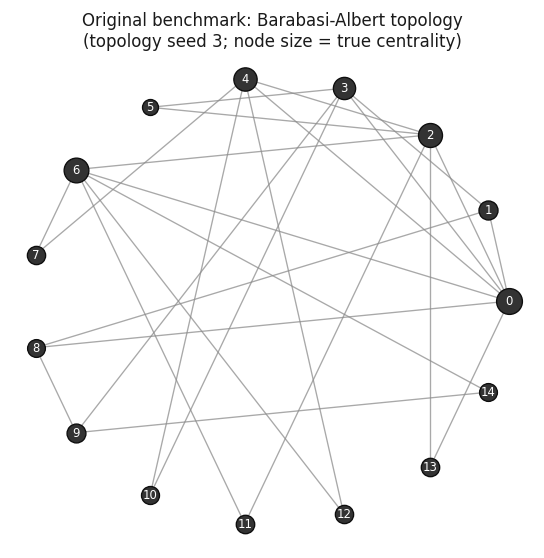

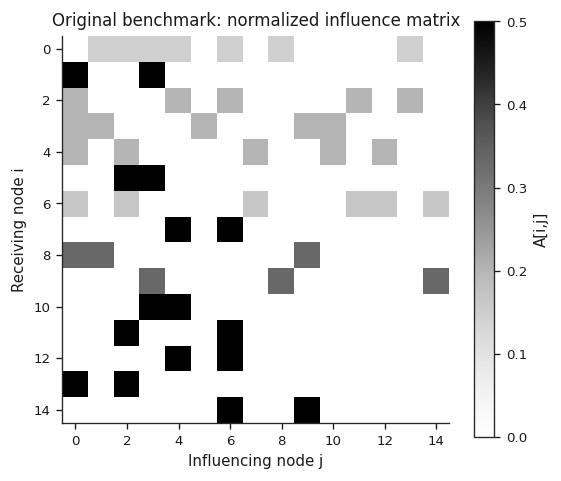

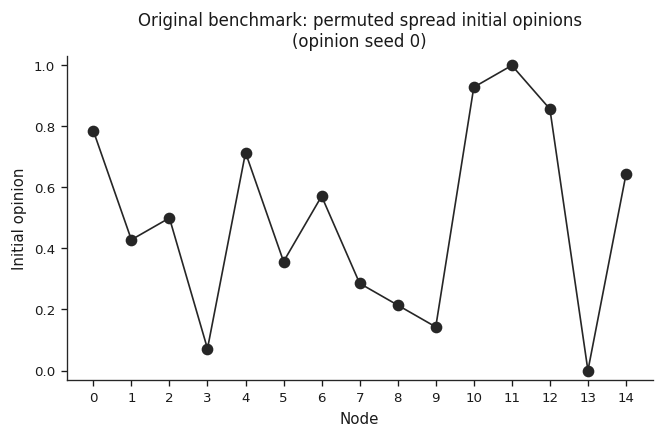

,family,n_nodes,graph_model,ba_m,canonical_topology_seed,canonical_opinion_seed,x0_min,x0_max,x0_mean,x0_std,max_true_centrality
0,barabasi_albert_spread,15,barabasi_albert,2,3,0,0.0,1.0,0.5,0.308607,0.145087


In [42]:
canonical_original_id = (
    "unstructured__laplacian__topo03__x00"
)
canonical_original = load_environment_definition(
    canonical_original_id
)

A_original = np.asarray(
    canonical_original["A"],
    dtype=float,
)
x0_original = np.asarray(
    canonical_original["x0"],
    dtype=float,
)
v_original = np.asarray(
    canonical_original["v_true"],
    dtype=float,
)

# Deterministic circular positions avoid any dependence on a graph-layout package.
angles = np.linspace(
    0.0,
    2.0 * np.pi,
    len(x0_original),
    endpoint=False,
)
positions = np.column_stack(
    [
        np.cos(angles),
        np.sin(angles),
    ]
)

# Draw each structural edge once. BA construction is structurally undirected,
# although row normalization can make A_ij and A_ji numerically different.
structural = (
    (A_original > 0)
    | (A_original.T > 0)
)

fig, ax = plt.subplots(figsize=(5.6, 5.3))

for i in range(len(x0_original)):
    for j in range(i + 1, len(x0_original)):
        if not structural[i, j]:
            continue

        ax.plot(
            [
                positions[i, 0],
                positions[j, 0],
            ],
            [
                positions[i, 1],
                positions[j, 1],
            ],
            linewidth=0.8,
            color=(
                "0.55"
                if PLOT_STYLE == "paper_bw"
                else None
            ),
            alpha=0.75,
            zorder=1,
        )

centrality_scaled = (
    v_original
    / max(v_original.max(), 1e-12)
)

for node in range(len(x0_original)):
    ax.scatter(
        [positions[node, 0]],
        [positions[node, 1]],
        s=70 + 170 * centrality_scaled[node],
        facecolors=(
            "0.20"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        edgecolors=(
            "0.05"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        linewidths=0.8,
        zorder=2,
    )
    ax.text(
        positions[node, 0],
        positions[node, 1],
        str(node),
        ha="center",
        va="center",
        fontsize=7,
        color=(
            "1.0"
            if PLOT_STYLE == "paper_bw"
            else "0.1"
        ),
        zorder=3,
    )

ax.set_title(
    "Original benchmark: Barabasi-Albert topology\n"
    "(topology seed 3; node size = true centrality)"
)
ax.set_axis_off()

save_figure(
    fig,
    "10_original_barabasi_albert_topology",
)
plt.show()
plt.close(fig)

# Adjacency matrix is useful because the model itself uses normalized weights.
fig, ax = plt.subplots(figsize=(5.2, 4.5))
image = ax.imshow(
    A_original,
    aspect="equal",
    interpolation="nearest",
    cmap=(
        "Greys"
        if PLOT_STYLE == "paper_bw"
        else "viridis"
    ),
)
ax.set_xlabel("Influencing node j")
ax.set_ylabel("Receiving node i")
ax.set_title(
    "Original benchmark: normalized influence matrix"
)
fig.colorbar(
    image,
    ax=ax,
    label="A[i,j]",
)

save_figure(
    fig,
    "10_original_barabasi_albert_adjacency",
)
plt.show()
plt.close(fig)

# Exact canonical spread-opinion initialization.
fig, ax = plt.subplots(figsize=(6.3, 3.5))
ax.plot(
    np.arange(len(x0_original)),
    x0_original,
    marker="o",
    linestyle="-",
    linewidth=1.0,
    color=(
        "0.15"
        if PLOT_STYLE == "paper_bw"
        else None
    ),
)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Node")
ax.set_ylabel("Initial opinion")
ax.set_xticks(np.arange(len(x0_original)))
ax.set_title(
    "Original benchmark: permuted spread initial opinions\n"
    "(opinion seed 0)"
)

save_figure(
    fig,
    "10_original_spread_initial_opinions",
)
plt.show()
plt.close(fig)

original_definition_summary = pd.DataFrame(
    [
        {
            "family": "barabasi_albert_spread",
            "n_nodes": len(x0_original),
            "graph_model": "barabasi_albert",
            "ba_m": 2,
            "canonical_topology_seed": 3,
            "canonical_opinion_seed": 0,
            "x0_min": float(x0_original.min()),
            "x0_max": float(x0_original.max()),
            "x0_mean": float(x0_original.mean()),
            "x0_std": float(x0_original.std()),
            "max_true_centrality": float(v_original.max()),
        }
    ]
)

display(original_definition_summary)

## Schematic topology plots for the structured families

The following plots are **schematic views** of the family construction.
They are intended to explain the topology families visually, not to display every exact edge weight.

For the broadcaster families, the two top nodes are the hubs and the bottom nodes are the leaves.  
For the HK families, the two central nodes are the inter-cluster bridge hubs.

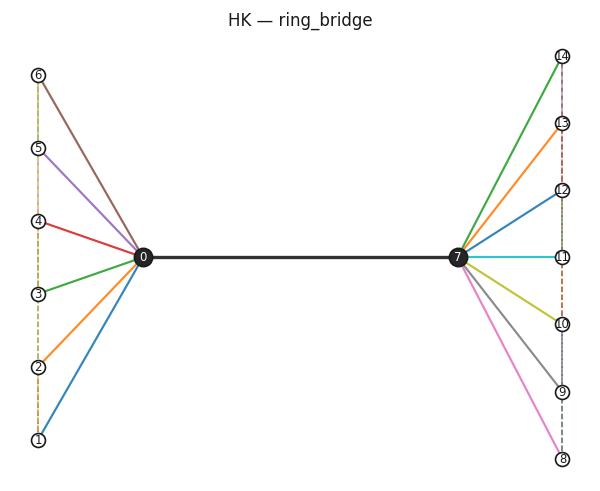

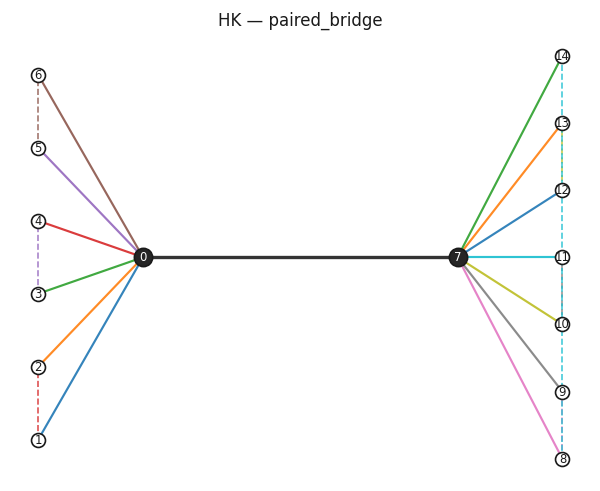

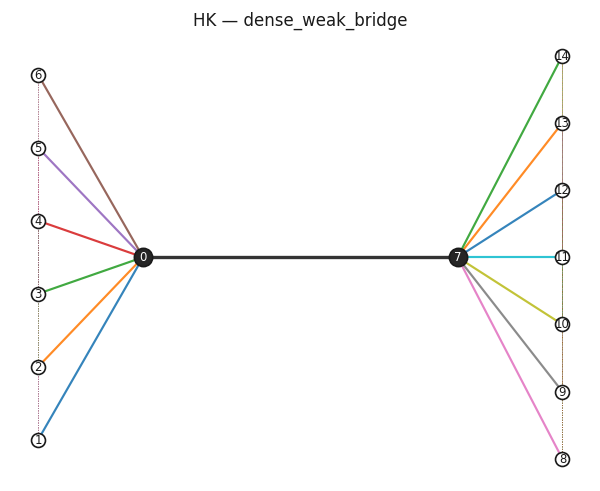

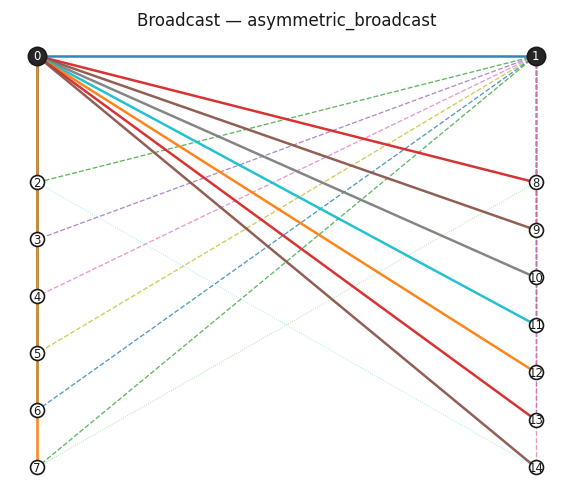

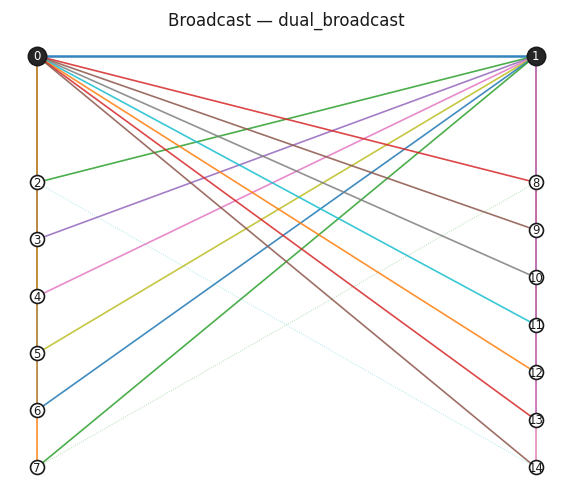

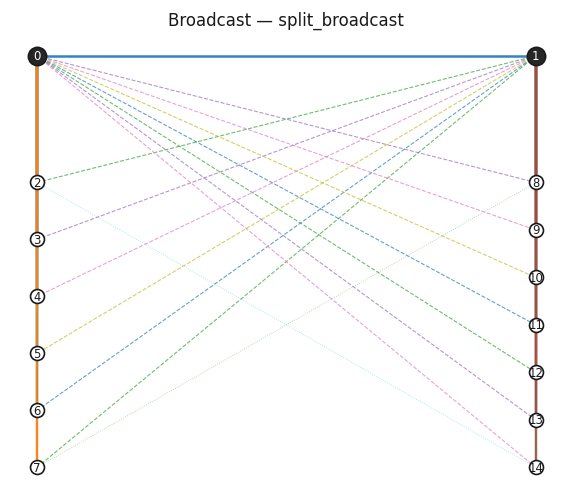

In [43]:
def draw_line(ax, p1, p2, *, linewidth=1.0, linestyle="-", color=None, alpha=1.0):
    xs = [p1[0], p2[0]]
    ys = [p1[1], p2[1]]
    ax.plot(xs, ys, linewidth=linewidth, linestyle=linestyle, color=color, alpha=alpha, zorder=1)


def hk_positions():
    pos = {}
    pos[0] = (-1.05, 0.0)
    pos[7] = (1.05, 0.0)

    left_leaves = [1, 2, 3, 4, 5, 6]
    right_leaves = [8, 9, 10, 11, 12, 13, 14]

    left_y = np.linspace(-0.95, 0.95, len(left_leaves))
    right_y = np.linspace(-1.05, 1.05, len(right_leaves))

    for idx, node in enumerate(left_leaves):
        pos[node] = (-1.75, float(left_y[idx]))
    for idx, node in enumerate(right_leaves):
        pos[node] = (1.75, float(right_y[idx]))

    return pos


def broadcaster_positions():
    pos = {
        0: (-0.95, 0.95),
        1: (0.95, 0.95),
    }

    leaves_left = list(range(2, 8))
    leaves_right = list(range(8, 15))

    y_left = np.linspace(0.35, -1.0, len(leaves_left))
    y_right = np.linspace(0.35, -1.0, len(leaves_right))

    for idx, node in enumerate(leaves_left):
        pos[node] = (-0.95, float(y_left[idx]))
    for idx, node in enumerate(leaves_right):
        pos[node] = (0.95, float(y_right[idx]))

    return pos


def draw_nodes(ax, pos, *, hubs, labels=True):
    for node, (x0, y0) in pos.items():
        is_hub = node in hubs
        if PLOT_STYLE == "paper_bw":
            facecolor = "0.15" if is_hub else "1.0"
            edgecolor = "0.1"
        else:
            facecolor = None
            edgecolor = None

        ax.scatter(
            [x0],
            [y0],
            s=120 if is_hub else 70,
            marker="o",
            facecolors=facecolor,
            edgecolors=edgecolor,
            linewidths=1.0,
            zorder=2,
        )
        if labels:
            ax.text(
                x0,
                y0,
                str(node),
                ha="center",
                va="center",
                fontsize=7,
                color=("1.0" if (PLOT_STYLE == "paper_bw" and is_hub) else "0.1"),
                zorder=3,
            )


def draw_hk_family(ax, family):
    pos = hk_positions()
    draw_line(
        ax,
        pos[0],
        pos[7],
        linewidth=2.0,
        linestyle="-",
        color=("0.2" if PLOT_STYLE == "paper_bw" else None),
    )

    left_cluster = [0, 1, 2, 3, 4, 5, 6]
    right_cluster = [7, 8, 9, 10, 11, 12, 13, 14]

    for node in left_cluster:
        if node != 0:
            draw_line(ax, pos[0], pos[node], linewidth=1.3, alpha=0.9)
    for node in right_cluster:
        if node != 7:
            draw_line(ax, pos[7], pos[node], linewidth=1.3, alpha=0.9)

    if family == "ring_bridge":
        left_leaves = [1, 2, 3, 4, 5, 6]
        right_leaves = [8, 9, 10, 11, 12, 13, 14]
        for group in [left_leaves, right_leaves]:
            seq = group + [group[0]]
            for a, b in zip(seq[:-1], seq[1:]):
                draw_line(ax, pos[a], pos[b], linewidth=0.9, linestyle="--", alpha=0.8)

    elif family == "paired_bridge":
        pairs = [(1, 2), (3, 4), (5, 6), (8, 9), (10, 11), (12, 13)]
        for a, b in pairs:
            draw_line(ax, pos[a], pos[b], linewidth=1.0, linestyle="--", alpha=0.8)
        draw_line(ax, pos[14], pos[8], linewidth=1.0, linestyle="--", alpha=0.8)

    elif family == "dense_weak_bridge":
        left_leaves = [1, 2, 3, 4, 5, 6]
        right_leaves = [8, 9, 10, 11, 12, 13, 14]
        for group in [left_leaves, right_leaves]:
            for i, a in enumerate(group):
                for b in group[i + 1:]:
                    draw_line(ax, pos[a], pos[b], linewidth=0.55, linestyle=":", alpha=0.55)

    draw_nodes(ax, pos, hubs={0, 7})
    ax.set_title(f"HK — {family}")
    ax.set_axis_off()


def draw_broadcast_family(ax, family):
    pos = broadcaster_positions()

    leaves = list(range(2, 15))
    group_a = list(range(2, 8))
    group_b = list(range(8, 15))

    draw_line(ax, pos[0], pos[1], linewidth=1.5, linestyle="-", alpha=0.9)

    for leaf in leaves:
        if family == "dual_broadcast":
            draw_line(ax, pos[0], pos[leaf], linewidth=1.0, alpha=0.85)
            draw_line(ax, pos[1], pos[leaf], linewidth=1.0, alpha=0.85)

        elif family == "asymmetric_broadcast":
            draw_line(ax, pos[0], pos[leaf], linewidth=1.5, alpha=0.95)
            draw_line(ax, pos[1], pos[leaf], linewidth=0.8, linestyle="--", alpha=0.75)

        elif family == "split_broadcast":
            primary_left = leaf in group_a
            if primary_left:
                draw_line(ax, pos[0], pos[leaf], linewidth=1.45, alpha=0.95)
                draw_line(ax, pos[1], pos[leaf], linewidth=0.65, linestyle="--", alpha=0.7)
            else:
                draw_line(ax, pos[1], pos[leaf], linewidth=1.45, alpha=0.95)
                draw_line(ax, pos[0], pos[leaf], linewidth=0.65, linestyle="--", alpha=0.7)

    ring_order = leaves + [leaves[0]]
    for a, b in zip(ring_order[:-1], ring_order[1:]):
        draw_line(ax, pos[a], pos[b], linewidth=0.5, linestyle=":", alpha=0.45)

    draw_nodes(ax, pos, hubs={0, 1})
    ax.set_title(f"Broadcast — {family}")
    ax.set_axis_off()


for family in ["ring_bridge", "paired_bridge", "dense_weak_bridge"]:
    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    draw_hk_family(ax, family)
    save_figure(fig, f"11_hk_schematic_{family}")
    plt.show()
    plt.close(fig)

for family in ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"]:
    fig, ax = plt.subplots(figsize=(5.9, 4.9))
    draw_broadcast_family(ax, family)
    save_figure(fig, f"11_broadcast_schematic_{family}")
    plt.show()
    plt.close(fig)

## Canonical initial-opinion profiles for the structured families

To complement the topology schematics, the next plots show the **initial opinions** used by the canonical `env00` instance of each structured family.
This makes the mechanism easier to interpret together with the schematics.

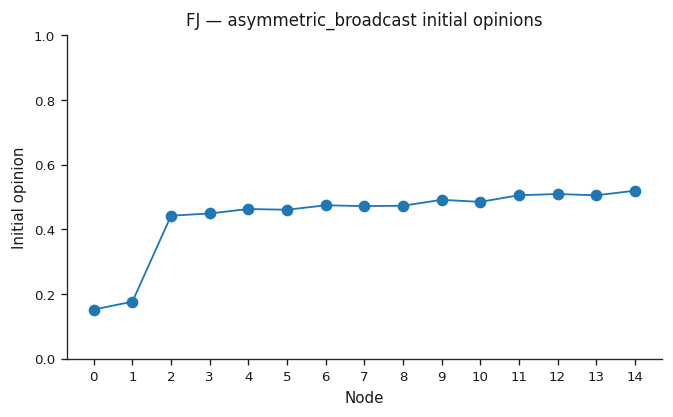

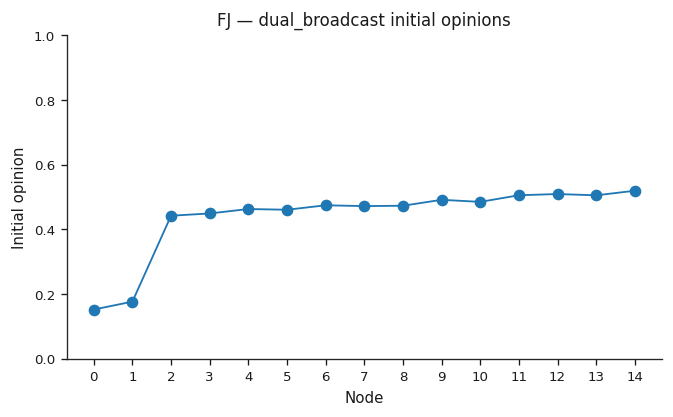

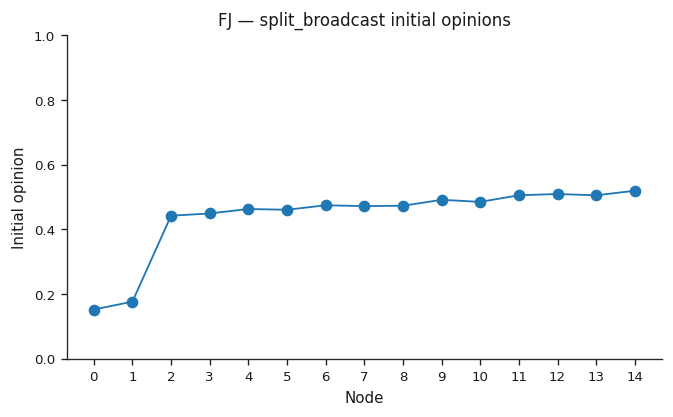

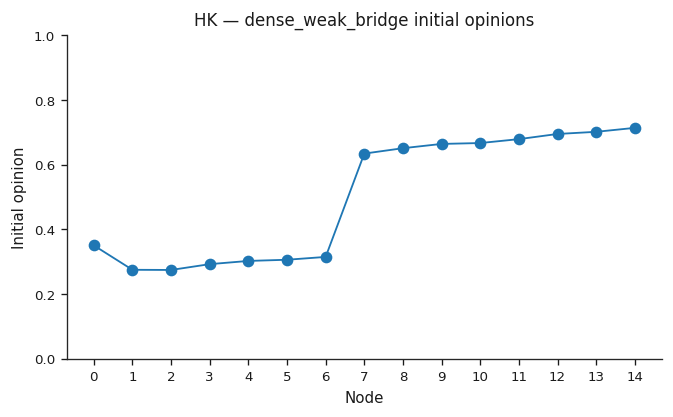

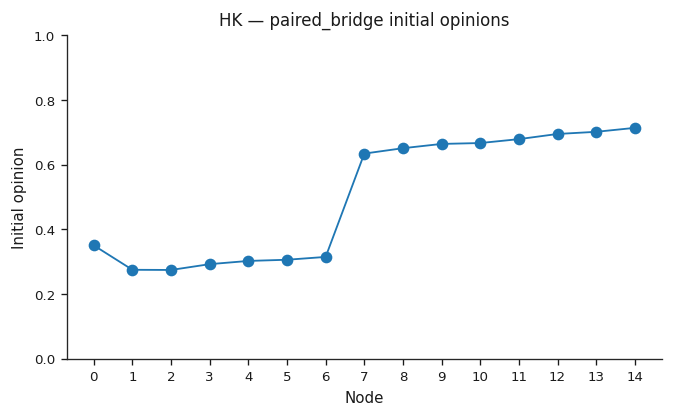

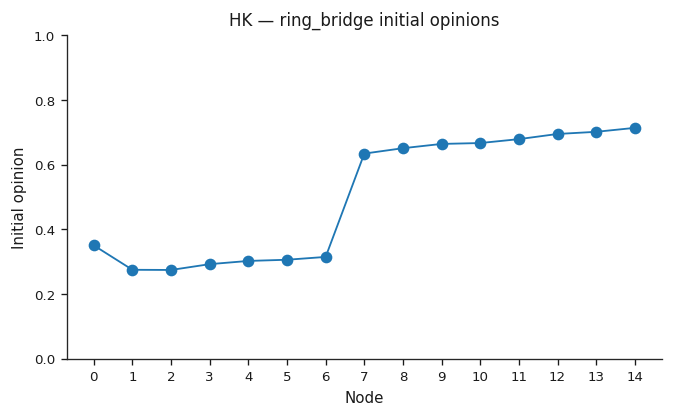

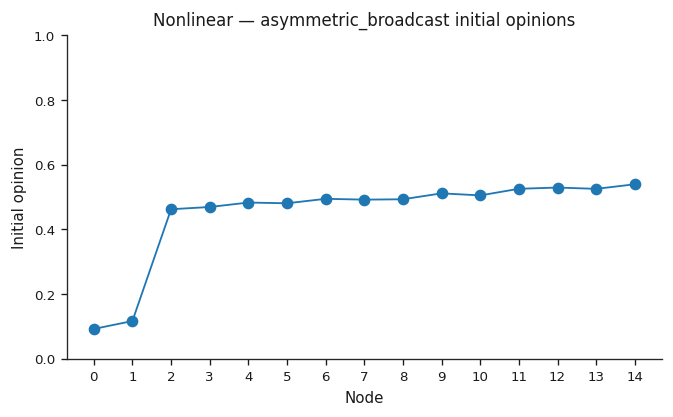

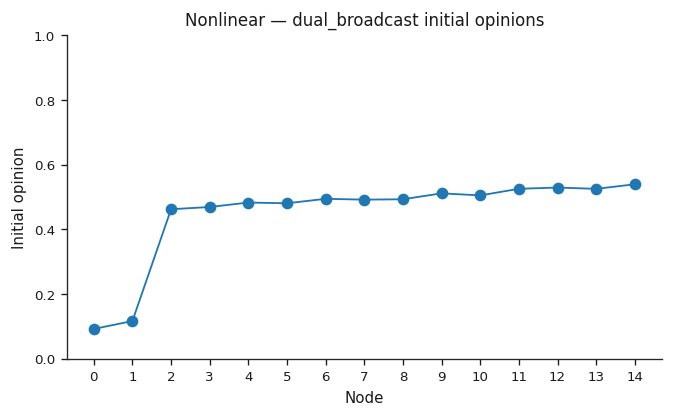

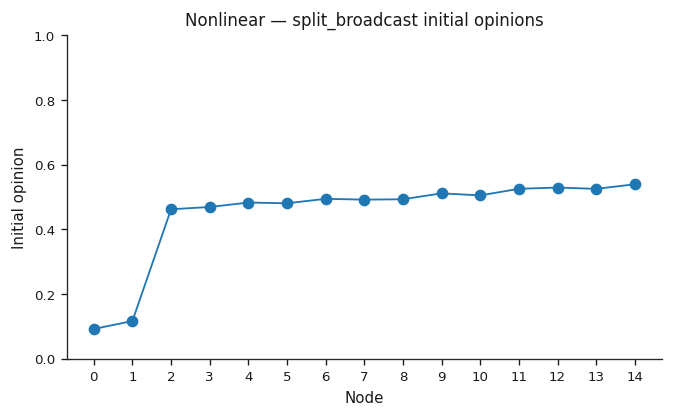

In [44]:
def canonical_structured_environment_id(dynamics, family):
    return f"structured__{dynamics}__{family}__env00"


def canonical_initial_state(environment_id):
    cache_dir = Path(ENV_INDEX[environment_id]["cache_dir"])
    baseline = load_baseline_rollout(environment_id, "no_control")
    return np.asarray(baseline["states"][0], dtype=float)


structured_pairs = [
    ("friedkinjohnsen", "asymmetric_broadcast"),
    ("friedkinjohnsen", "dual_broadcast"),
    ("friedkinjohnsen", "split_broadcast"),
    ("hegselmannkrause", "dense_weak_bridge"),
    ("hegselmannkrause", "paired_bridge"),
    ("hegselmannkrause", "ring_bridge"),
    ("nonlinearinfluence", "asymmetric_broadcast"),
    ("nonlinearinfluence", "dual_broadcast"),
    ("nonlinearinfluence", "split_broadcast"),
]

for dynamics, family in structured_pairs:
    environment_id = canonical_structured_environment_id(dynamics, family)
    x0 = canonical_initial_state(environment_id)

    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    ax.plot(
        np.arange(len(x0)),
        x0,
        marker="o",
        linestyle="-",
        linewidth=1.1,
    )
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Node")
    ax.set_ylabel("Initial opinion")
    ax.set_title(f"{DYNAMICS_LABELS[dynamics]} — {family} initial opinions")
    ax.set_xticks(np.arange(len(x0)))

    save_figure(fig, f"12_initial_opinions_{dynamics}_{family}")
    plt.show()
    plt.close(fig)

## Final analysis audit

In [45]:
audit = pd.DataFrame(
    [
        {
            "study_name": RUN_MANIFEST["study_name"],
            "git_commit": RUN_MANIFEST["git_commit"],
            "config_hash": RUN_MANIFEST["config_hash"],
            "implementation_hash": RUN_MANIFEST[
                "implementation_hash"
            ],
            "plot_style": PLOT_STYLE,
            "distinct_environments": len(env_level_df),
            "unstructured_environments": int(
                (
                    env_level_df["scenario_class"]
                    == "unstructured_random"
                ).sum()
            ),
            "structured_environments": int(
                (
                    env_level_df["scenario_class"]
                    == "structured_mechanism"
                ).sum()
            ),
            "learned_seed_runs": len(learned_df),
            "explicit_exploration_campaigns": (
                RUN_MANIFEST[
                    "scientific_config"
                ]["exploration_campaigns"]
            ),
        }
    ]
)

display(audit)

audit.to_csv(
    RESULTS_DIR / f"analysis_audit_{PLOT_STYLE}.csv",
    index=False,
)

print("Analysis complete.")
print("Tables:", RESULTS_DIR)
print("Plots:", PLOT_DIR)

,study_name,git_commit,config_hash,implementation_hash,plot_style,distinct_environments,unstructured_environments,structured_environments,learned_seed_runs,explicit_exploration_campaigns
0,broad_all_dynamics_multitopology_multiseed,37c0d5e,110bb71b67ca12e2ffd4f5e46364959057b7f553f16442...,e37ff12c7c61152c99e440164add5b0916cec589ccc7cc...,paper_bw,195,150,45,585,0


Analysis complete.
Tables: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed
Plots: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_17_broad_all_dynamics_multitopology_multiseed\plots_paper_bw
